# Introduction

Neural networks are powerful function approximators, but standard training usually produces only a single estimate of their parameters. In probabilistic machine learning, we are instead interested in uncertainty over parameters and predictions.

In this notebook, we consider a Bayesian view of neural networks. We first train a deterministic neural network and then approximate its posterior distribution using the Laplace approximation around the MAP estimate. By locally linearizing the network, parameter uncertainty can be propagated into function space, producing an approximate Gaussian process over network outputs.

We will use this framework to study predictive uncertainty, the effect of the parameter prior, and the behavior of the model away from the training data.

# Imports and Setup

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt
import optax
import torch
from jax import random
from jaxtyping import Array, Float
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from src.gaussian import GaussianProcess

In [3]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "owb", [(255/255, 127/255, 14/255), (1, 1, 1), (31/255, 119/255, 180/255)], N = 1024
)

dw = matplotlib.colors.LinearSegmentedColormap.from_list(
    'wb', [[0.21568627, 0.25490196, 0.29019608], (1, 1, 1)], N = 1024
)

In [4]:
def plot_field(
    X1,
    X2,
    field,
    X_train,
    train_values,
    X_test = None,
    test_values = None,
    *,
    ax = None,
    cmap = cmap,
    vmin = None,
    vmax = None,
    levels = 30,
    title = None
):
    if ax is None:
        ax = plt.gca()
    
    contour = ax.contourf(
        X1,
        X2,
        field,
        levels=levels,
        cmap=cmap,
        alpha=0.5,
        vmin=vmin,
        vmax=vmax,
    )

    ax.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=train_values,
        cmap=cmap,
        s=20,
        edgecolor=[0.21568627, 0.25490196, 0.29019608],
        vmin=vmin,
        vmax=vmax,
        label="train" if X_test is not None else "data",
    )

    if X_test is not None:
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=test_values,
            cmap=cmap,
            s=30,
            edgecolor=[0.21568627, 0.25490196, 0.29019608],
            marker="^",
            vmin=vmin,
            vmax=vmax,
            label="test",
        )

    if title is not None:
        ax.set_title(title)

    return contour

# Deterministic Neural Networks

## Deterministic Network

Let us have a Neural Network with some parameters
$$ f(x; \theta) $$
where $x$ is the input and $\theta$ are the parameters of the network.

Let us also have a dataset
$$ D = \left\{ (x_1, y_1), (x_2, y_2), \dots, (x_n, y_n) \right\} $$

When we train the network we obtain optimal parameter vector $\theta^*$, so our prediction becomes
$$ f(x; \theta^*) $$
note that the ordinary neural network training gives us one particular parameter vector. Thus, the parameter $\theta^*$ is fixed, meaning that there is no parameter uncertainty.

However, if we treat the parameter as a random variable, we obtain the Bayesian Neural Network
$$ \theta \sim p(\theta \mid X, y) $$

That is the main object in this notebook.

## Binary Classification

Let us consider a binary classification example with $y_i \in \{ 0, 1 \}$. Let our neural network give a real-valued output 
$$ f(x; \theta) \in \mathbb{R} $$

Then, as in the previous notebook we convert it into probability using sigmoid function
$$ p(y = 1 \mid x, \theta) = \sigma(f(x; \theta)), \quad \sigma(z) = \frac{1}{1 + e^{-z}} $$

Let, for simplicity,
$$ f_i = f(x_i; \theta) $$

We can extend this probability to the entire dataset under the iid assumption:
$$ p(y \mid X, \theta) = \prod_{i=1}^n p(y_i \mid x_i, \theta) = \prod_{i=1}^n \sigma(f_i)^{y_i} (1 - \sigma(f_i)^{1 - y_i} $$

Taking the logarithm we can obtain
$$ \ell(\theta) = \log p(y \mid X, \theta) = \sum_{i=1}^n \log \sigma(f_i)^{y_i} (1 - \sigma(f_i)^{1 - y_i} $$

This is the log-likelihood of the model. It will later be used in the Bayes' formula to obtain the posterior.

## MAP Training

We can treat the parameters as a distribution rather than a vector, so let
$$ \theta \sim \mathcal{N}(m, V) $$
be a prior distribution of the parameters.

Then, using Bayes' formula:
$$ p(\theta \mid X, y) \propto p(y \mid X, \theta) p(\theta) $$

In the previous notebook we have considered similar problem but with 
$$ f(x) = \phi(x)^T w $$
being explicitly linear function in $w$. Here we extend this idea to general differentiable operators $f(x; \theta)$. So the transition is
$$ f(x) = \phi(x)^T w \to f(x; \theta) $$

Since we already know both prior and likelihood, we can write our log-posterior:
$$ \log p(\theta \mid X, y) \propto \ell(\theta) - \frac{1}{2} (\theta - m)^T V^{-1} (\theta - m) + \text{const.} $$

Optimizing this log-posterior we can obtain the Maximum a Posteriori solution for the parameters
$$ \theta_{\text{MAP}} = \arg\max \log p(\theta \mid X, y) $$

In this notebook we will similarly center our Laplace approximation on this point and calculate the local curvature.

# Example: Two Moons Dataset

Now let us obtain an MAP estimate using a neural network. The loss function will be constructed as negative log-posterior, i.e.
$$ -\log p(\theta \mid X, y) = \underbrace{-\sum_{i=1}^n \left[ y_i \log \sigma(f_i) + (1 - y_i) \log (1 - \sigma(f_i)) \right]}_{\text{BCE}} + \frac{1}{2} (\theta - m)^T V^{-1} (\theta - m) $$
In this example we will assume that
$$ \theta \sim \mathcal{N}(0, I) $$
for simplicity, since in this settings the log prior becomes
$$ \log p(\theta) = -\frac{1}{2} (\theta - m)^T V^{-1} (\theta - m) = -\frac{1}{2} \| \theta \|^2 $$

The likelihood loss will be computed using Binary Cross-Entropy (BCE) loss.

So, the total negative log-posterior is
$$ -\log p(\theta \mid X, y) = \text{BCE} + \frac{1}{2} \| \theta \|^2 $$

## Dataset

Text(0.5, 1.0, 'Two Moons Dataset')

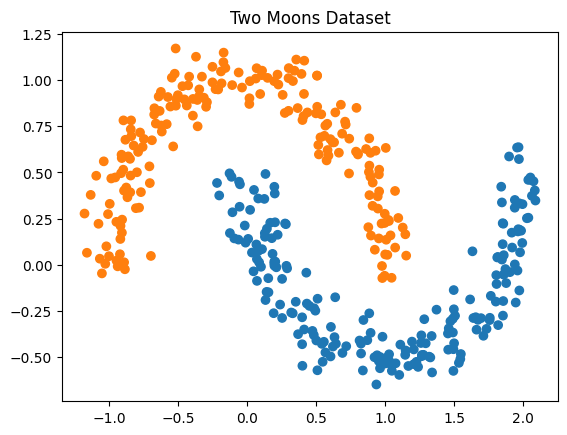

In [5]:
X, y = make_moons(n_samples = 500, shuffle = True, noise = 0.1, random_state = 47)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, random_state = 47)

plt.scatter(X_train[:, 0], X_train[:, 1], c = y_train, cmap = cmap)
plt.title("Two Moons Dataset")

In [6]:
x1 = jnp.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
x2 = jnp.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100)

X1, X2 = jnp.meshgrid(x1, x2)
X_grid = jnp.stack((X1.flatten(), X2.flatten()), axis = 1)

## Training the MLP

In [7]:
LAYER_SIZES = [2, 64, 64, 1]

NUM_EPOCHS = 300
LEARNING_RATE = 0.001
BATCH_SIZE = 64
KEY = jax.random.key(47)

In [8]:
class MLP(eqx.Module):
    layers: list[eqx.nn.Linear]

    def __init__(self, key: Array, layer_sizes: list[int]):
        keys = random.split(key, len(layer_sizes) - 1)

        self.layers = [
            eqx.nn.Linear(layer_sizes[i], layer_sizes[i+1], key = keys[i]) 
            for i in range(len(layer_sizes) - 1)
        ]

    def __call__(self, X: Float[Array, "N D"]) -> Float[Array, "N 1"]:
        for i in range(len(self.layers) - 1):
            X = self.layers[i](X)
            X = jax.nn.relu(X)

        X = self.layers[-1](X)

        return X

KEY, model_key = random.split(KEY, 2)
model = MLP(model_key, LAYER_SIZES)

In [9]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        super().__init__()

        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MyDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = len(train_dataset), shuffle = False)

test_dataset = MyDataset(X_test, y_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = len(test_dataset), shuffle = False)

In [10]:
@eqx.filter_jit
def loss_fn(model, X, y, prior_var = 1.0):
    logits = jax.vmap(model)(X).squeeze(-1)

    l2 = sum(
        jnp.sum(p**2)
        for p in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array))
    )

    loss = optax.losses.sigmoid_binary_cross_entropy(logits, y).sum() + 0.5 / prior_var * l2

    return loss

@eqx.filter_jit
def compute_accuracy(model, X, y):
    logits = jax.vmap(model)(X).squeeze(-1)
    y_pred = (logits > 0).astype(int)

    return (y_pred == y).mean()

def evaluate_model(model, loader, prior_var = 1.0):
    loss = 0.0
    acc = 0.0

    for X_batch, y_batch in loader:
        X_batch = jnp.asarray(X_batch.numpy())
        y_batch = jnp.asarray(y_batch.numpy())

        loss += loss_fn(model, X_batch, y_batch, prior_var = prior_var)
        acc += compute_accuracy(model, X_batch, y_batch) * len(y_batch)

    loss /= len(loader.dataset)
    acc /= len(loader.dataset)

    return loss, acc

In [11]:
def train(model, train_loader, test_loader, optimizer, num_epochs, prior_var = 1.0):
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    @eqx.filter_jit
    def make_step(model, opt_state, X_batch, y_batch):
        loss, grads = eqx.filter_value_and_grad(loss_fn)(model, X_batch, y_batch, prior_var = prior_var)

        updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_array))

        model = eqx.apply_updates(model, updates)

        return model, opt_state, loss

    train_loss_curve = []
    test_loss_curve = []

    pbar = tqdm(range(num_epochs), desc = 'Training')
    for epoch in pbar:
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = jnp.asarray(X_batch.numpy())
            y_batch = jnp.asarray(y_batch.numpy())

            model, opt_state, loss = make_step(model, opt_state, X_batch, y_batch)

            train_loss += loss

        train_loss /= len(train_loader.dataset)

        test_loss, test_acc = evaluate_model(model, test_loader)

        train_loss_curve.append(train_loss)
        test_loss_curve.append(test_loss)

        if epoch % 10 == 9:
            pbar.set_postfix(
                epoch = epoch + 1,
                train_loss = train_loss.item(),
                test_loss = test_loss.item(),
                test_accuracy = test_acc.item(),
            )

    return model, (train_loss_curve, test_loss_curve)

In [12]:
optimizer = optax.adam(learning_rate = LEARNING_RATE)

model, losses = train(model, train_loader, test_loader, optimizer, num_epochs = NUM_EPOCHS)

Training: 100%|██████████| 300/300 [00:02<00:00, 118.13it/s, epoch=300, test_accuracy=1, test_loss=0.386, train_loss=0.124]   


Text(0.5, 1.0, 'Loss over Epochs')

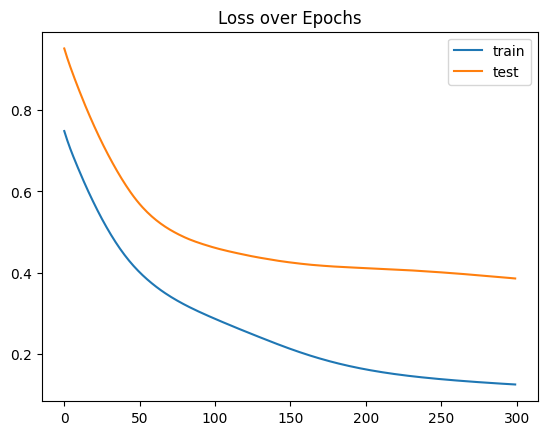

In [13]:
plt.plot(losses[0], label = "train")
plt.plot(losses[1], label = "test")
plt.legend()
plt.title("Loss over Epochs")

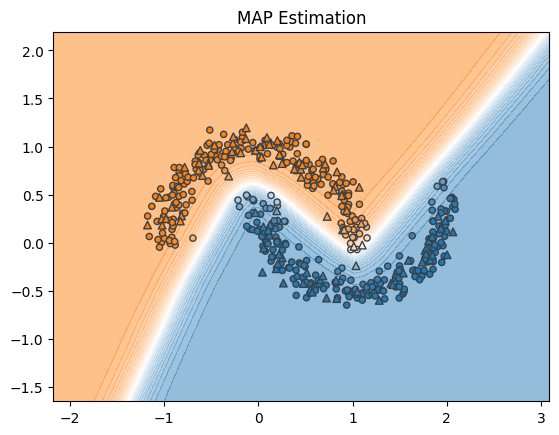

In [14]:
plot_field(
    X1,
    X2,
    jax.nn.sigmoid(jax.vmap(model)(X_grid)).reshape(X1.shape),
    X_train,
    jax.nn.sigmoid(jax.vmap(model)(X_train)),
    X_test = X_test,
    test_values = jax.nn.sigmoid(jax.vmap(model)(X_test)),
    vmin = 0,
    vmax = 1,
    levels = 30,
    title = "MAP Estimation"
)

So, the MLP works fine for this problem. But it is deterministic and we cant estimate the uncertainty using it.

# Bayesian Neural Network

## Parameter Posterior

We have obtained a fitted parameter vector
$$ \theta_{\text{MAP}} $$
Bayesian Neural Network considers the parameter as a distribution instead:
$$ \theta \sim p(\theta \mid D) $$

MLP also modeled $\theta$ as a random variable, but the MAP returns a single value of that random variable. The distribution itself is not used in the optimization, we are just trying to find the optimal value of $\theta$ that maximizes the log-posterior. BNN, in contrast, uses the distribution fully.

## Posterior Predictive Distribution

With MAP, the prediction is simply made using
$$ p(y_* = 1 \mid x_*, D) = \sigma(f(x_*; \theta_{\text{MAP}})) $$
The Bayesian Neural Network uses the full distribution 
$$ p(y_* = 1 \mid x_*, D) = \int p(y_* = 1 \mid x_*, \theta) p(\theta \mid D) d\theta $$
and, therefore,
$$ p(y_* = 1 \mid x_*, D) = \int \sigma (f(x_*; \theta)) p(\theta \mid D) d\theta $$
This is very similar to the integral we have used in [Logistic Regression notebook](./7.%20Logistic%20Regression.ipynb). The workflow will be similar as well:
$$ \boxed{\text{MAP} \to \text{Laplace} \to \text{Sampling}} $$

## Why Exact Inference is Difficult

In the previous notebooks we mostly could easily solve the predictive integrals exactly since we used Gaussian distributions or at least conjugate prior. In this case, similarly as in the logistic regression, Gaussian prior and Bernoulli likelihood are not conjugate. That is why we will need to approximate the distribution using Laplace approximation.

Neural networks make this situation even worse since now we have a nonlinear function with possibly thousands of parameters instead of a linear function with a relatively small weight vector.

So, before the Laplace approximation we should also linearize the network with respect to the parameter $\theta$.

# Linearization

As we know, the neural network
$$ f(x; \theta) $$
is nonlinear in parameters. Let us specify our trained MLP as
$$ f(x; \theta_{\text{MAP}}) $$
To be able to sample from the posterior distribution we need at least somehow familiar form, that is why in logistic regression we have used Laplace approximation to make the posterior locally Gaussian:
$$ w \mid x, D \approx \mathcal{N}(\phi(x)^T w_{\text{MAP}}, \Sigma) $$
We could directly do so since the model is linear in weights. Now, if we treat the obtained solution as the distribution mean
$$ \theta \mid x, D \approx \mathcal{N}(f(x; \theta_{\text{MAP}}), \Sigma) $$
we pass a Gaussian $\theta$ to the model and the output is not generally Gaussian.

That is why we want a linear approximation of our model to be passed to the Laplace approximation rather than the model itself.

## First-Order Taylor Expansion

We have obtained a model
$$ f(x; \theta_{\text{MAP}}) $$
Since it is a differentiable function in $\theta$, we can run a first-order Taylor expansion around the MAP estimator $\theta_{\text{MAP}}$:
$$ f(x; \theta) \approx f(x; \theta_{\text{MAP}}) + J(x) (\theta - \theta_{\text{MAP}}) $$
where $J(x)$ is the gradient of the model at a point $\theta_{\text{MAP}}$:
$$ J(x) = \nabla_{\theta} f(x; \theta) \bigm|_{\theta = \theta_{\text{MAP}}} \in \mathbb{R}^{d_{out} \times P} $$
where $d_{out}$ is the dimensionality of the model output and $P$ is the number of parameters.

So, our linearized network is
$$ \tilde{f}(x; \theta) = f(x; \theta_{\text{MAP}}) + J(x)\underbrace{(\theta - \theta_{\text{MAP}})}_{\delta \theta} $$

Higher order terms are ignored here because we want a linear function.

## Neural Tangent Features

In logistic regression we had
$$ f(x) = \phi(x)^T w $$
with a predefined feature map $\phi(x)$.
Now we have
$$ \tilde{f}(x; \theta) = f(x; \theta_{\text{MAP}}) + J(x) \delta \theta $$
Here one can associate
$$ \phi(x)^T w \leftrightarrow J(x) \delta \theta $$
with
$$ \phi(x) \leftrightarrow J(x), \quad w \leftrightarrow \delta \theta $$
but the difference is:
* in loogistic regression, we define the feature map in advance
* in neural network, the model gives us $J(x) = \nabla_{\theta} f(x; \theta) \bigm|_{\theta = \theta_{\text{MAP}}}$ by itself

So, roughy speaking, the Jacobian $J(x)$ can be interpreted as a learned local feature map.

The Jacobian $J(x)$ is often called a **neural tangent feature map** because it describes the tangent of the network with respect to its parameters at the expansion point.

## Interpretation of Jacobian

In this section, let us take a closer look on the Jacobian. For a single parameter $\theta_j$:
$$ \frac{\partial f(x; \theta)}{\partial \theta_j} $$
measure how sensitive is the parameter $\theta_j$ for a data point $x$. The entire Jacobian
$$ J(x) = \begin{bmatrix} \frac{\partial f(x; \theta)}{\partial \theta_1} & \dots & \frac{\partial f(x; \theta)}{\partial \theta_P} \end{bmatrix} $$
then describes how sensitive the entire model is.

Suppose Laplace gives us
$$ \delta \theta = \theta - \theta_{\text{MAP}} \sim \mathcal{N}(0, \Sigma_{\theta}) $$

Then, multiplying the Jacobian to the $\delta \theta$ gives us
$$ J(x) \delta \theta \sim \mathcal{N}(0, J(x) \Sigma_{\theta} J(x)^T) $$
and the entire linearized model is
$$ \tilde{f}(x) = f(x; \theta_{\text{MAP}}) + J(x) \delta \theta \sim \mathcal{N}(f(x; \theta_{\text{MAP}}), J(x) \Sigma_{\theta} J(x)^T) $$
which is a Gaussian Process with a mean function
$$ f(x; \theta_{\text{MAP}}) $$
and a covariance kernel
$$ k(x, x') = J(x) \Sigma_{\theta} J(x')^T $$

Keep in mind that the linearized model $\tilde{f}$ is linear with respect to parameters, not data.

# Laplace Approximation

## MAP Solution

Recall a posterior for our problem:
$$ p(\theta \mid X, y) \propto p(y \mid X, \theta) p(\theta) $$
analogously, we can negate the logarithms of the functions above and obtain a form
$$ U(\theta) := -\log p(\theta \mid X, y) \propto -\log p(y \mid X, \theta) -\log p(\theta) $$
Where $U$ is the negative log-posterior.

Then we defined an MAP solution that maximizes the posterior (or, equivalently, minimizes the negative log-posterior)
$$ \theta_{\text{MAP}} = \arg \max_{\theta} p(\theta \mid X, y) = \arg \min{\theta} U(\theta) $$

Then, since the obtained solution is an optima, the gradient of the objective function is equal to $0$ at that point:$
$$ \nabla_{\theta} U(\theta_{\text{MAP}}) = 0 $$

Then, Laplace will approximate the posterior around the point $\theta_{\text{MAP}}$.

## Local Gaussian Posterior

Let us take a second-order Taylor expansion of the negative log-posterior around $\theta_{\text{MAP}}$:
$$ U(\theta) \approx U(\theta_{\text{MAP}}) + g_{\theta_{\text{MAP}}}^T (\theta - \theta_{\text{MAP}}) + \frac{1}{2} (\theta - \theta_{\text{MAP}})^T H_{\theta_{\text{MAP}}} (\theta - \theta_{\text{MAP}}) $$

where:
* $g_{\theta_{\text{MAP}}} = \nabla_{\theta} U \bigm|_{\theta = \theta_{\text{MAP}}} $
* $H_{\theta_{\text{MAP}}} = \nabla_{\theta}^2 U \bigm|_{\theta = \theta_{\text{MAP}}}$

But in the previous subsection we have claimed
$$ g_{\theta_{\text{MAP}}} = 0 $$

So, Taylor expansion becomes
$$ U(\theta) \approx U(\theta_{\text{MAP}}) + \frac{1}{2} (\theta - \theta_{\text{MAP}})^T H_{\theta_{\text{MAP}}} (\theta - \theta_{\text{MAP}}) $$

Now, since
$$ p(\theta \mid X, y) \propto \exp(-U(\theta)) $$
we can write
$$
\begin{aligned}
p(\theta \mid X, y) & \propto \exp(-U(\theta)) \\
&= \exp \left[ -U(\theta_{\text{MAP}}) - \frac{1}{2} (\theta - \theta_{\text{MAP}})^T H_{\theta_{\text{MAP}}} (\theta - \theta_{\text{MAP}}) \right] \\
&= \underbrace{\exp \left[ -U(\theta_{\text{MAP}}) \right]}_{\text{const.}} \exp \left[ -\frac{1}{2} (\theta - \theta_{\text{MAP}})^T H_{\theta_{\text{MAP}}} (\theta - \theta_{\text{MAP}}) \right] \\
&= C \exp \left[ -\frac{1}{2} (\theta - \theta_{\text{MAP}})^T H_{\theta_{\text{MAP}}} (\theta - \theta_{\text{MAP}}) \right] \\
& \approx \mathcal{N}(\theta; \theta_{\text{MAP}}, H^{-1})
\end{aligned}
$$
Let us call the latter distribution density as $q$:
$$ q(\theta \mid X, y) = \mathcal{N}(\theta; \theta_{\text{MAP}}, H^{-1}) $$

## Posterior Covariance

### Interpretation

We obtained the posterior covariance
$$ \Sigma_{\theta} = H^{-1} $$
since for Gaussian
$$ \mathcal{\mu, \Sigma} $$
its log-density contains
$$ (x - \mu)^T \Sigma^{-1} (x - \mu) $$
and our approximated log-posterior contains
$$ (\theta - \theta_{\text{MAP}})^T H (\theta - \theta_{\text{MAP}}) $$
thus,
$$ \Sigma_{\theta}^{-1} = H \Rightarrow \Sigma = H^{-1} $$

This leads to the following interpretation:
* small curvature $\Rightarrow$ large posterior variance
* large curvature $\Rightarrow$ small posteriir variance

### Connection to Prior and Likelihood

Also if we consider the initial form of the negative log-posterior:
$$ U(\theta) = -\log p(y \mid X, \theta) - \log p(\theta) $$
we can see that
$$ H = H_{\text{likelihood}} + H_{\text{prior}} $$

and for the general Gaussian prior
$$ \theta \sim \mathcal{N}(m, V) $$
the Hessian is
$$ H_{\text{prior}} = V^{-1} $$

So, the posterior Hessian can be written as
$$ H = H_{\text{likelihood}} + V^{-1} $$
and the approximated covariance is then
$$ \Sigma_{\theta} = \left( H_{\text{likelihood}} + V^{-1} \right)^{-1} $$

### Back to Linearized Model

If we recall the linearized neural network we obtained:
$$ \tilde{f}(x; \theta) = f(x; \theta_{\text{MAP}}) + J(x) \delta \theta $$

Since
$$ \delta \theta = \theta - \theta_{\text{MAP}} $$
and we just found
$$ \theta \mid X, y \sim \mathcal{N} (\theta_{\text{MAP}}, \Sigma_{\theta}) $$
we can claim that
$$ \delta \theta \sim \mathcal{N}(0, \Sigma_{\theta}) $$

Then, we get
$$ \boxed{\tilde{f}(x; \theta) = f(x; \theta_{\text{MAP}}) + J(x) \delta \theta, \quad \delta \theta \sim \mathcal{N}(0, \Sigma_{\theta})} $$

# Generalized Gauss-Newton Curvature

In the previous section, we have found
$$ H = H_{\text{likelihood}} + V^{-1} $$
In this section we will try to find the curvature of the likelihood function.

## GGN Derivation

Recall the negative log-likelihood:
$$ \ell(\theta) = - \log(y \mid X, \theta) $$
or, for one observation:
$$ \ell_i(\theta) = -\log (y_i \mid x_i, \theta) $$

Now we want to differentiate the negative log-likelihood with respect to the parameters:
$$ \nabla_{\theta} \ell_i(\theta) $$

Let us define the following for convenience
$$ f_i = f(x_i; \theta) $$
$$ J_i = J(x_i) = \nabla_{\theta} (f(x_i)) $$

Using the dependence
$$ \ell_i(\theta) = \ell_i(f_i(\theta)) $$
and the Jacobian from the previous sections
we can apply the chain rule for differentiation
$$ \nabla_{\theta} \ell_i = \frac{\partial \ell_i}{\partial f_i} \underbrace{\frac{\partial f_i}{\partial \theta}}_{J_i} = J_i \frac{\partial \ell_i}{\partial f_i} $$
The second derivative is then
$$ 
\begin{aligned}
\nabla_{\theta}^2 \ell_i &= \nabla_{\theta} \left( J_i \frac{\partial \ell_i}{\partial f_i} \right) \\
&= J_i \nabla_{\theta} \frac{\partial \ell_i}{\partial f_i} + \frac{\partial \ell_i}{\partial f_i} \nabla_{\theta} J_i \\
&= J_i^T \frac{\partial^2 \ell_i}{\partial f_i^2} J_i + \frac{\partial \ell_i}{\partial f_i} \frac{\partial^2 f_i}{\partial \theta^2}
\end{aligned}
$$

So, the likelihood has two sources of curvature:
* curvature coming from the loss with respect to the model parameters
* curvature of the model itself with respect to its parameters

However, we are considering the linearized estimation of the model, not the model itself. So, the curvature of the model with respect to its parameters is zero, i.e. for :
$$ \tilde{f}(x_i) = f(x_i; \theta_{\text{MAP}}) + J_i(x) \delta \theta  $$
we have
$$ \nabla_{\theta}^2 \tilde{f} = 0 $$

That is why GGN discards the second term of the curvature and computes only
$$ \nabla_{\theta}^2 \ell_i = J_i^T \frac{\partial^2 \ell_i}{\partial f_i^2} J_i $$
and for the whole dataset this quantity becomes
$$ G = \sum_{i} \nabla_{\theta}^2 \ell_i = \sum_i J_i^T \frac{\partial^2 \ell_i}{\partial f_i^2} J_i $$

### Binary Classification Example

For our binary classification we have the negative log-likelihood of
$$ \ell_i = -y_i \log p_i - (1 - y_i) \log (1 - p_i), \quad p_i = \sigma(f_i) $$

Then, the first derivative with respect to logit is:
$$ \frac{\partial \ell_i}{\partial f_i} = p_i - y_i $$
and the second one is
$$ \frac{\partial^2 \ell_i}{\partial f_i^2} = p_i (1 - p_i) $$

Therefore, the GGN is
$$ G = \sum_{i} J_i^T \frac{\partial^2 \ell_i}{\partial f_i^2} J_i = \sum_i p_i (1 - p_i) J_i^T J_i $$

Or, stacking the Jacobians to one matrix
$$ J = \begin{bmatrix} J_1^T \\ \vdots \\ J_n^T \end{bmatrix} \in \mathbb{R}^{n \times P} $$
and setting
$$ W = \text{diag} (p_1 (1 - p_1), \dots, p_n(1 - p_n)) \in \mathbb{R}^{n \times n} $$
we can obtain the matrix form of $G$:
$$ G = J^T W J \in \mathbb{R}^{P \times P} $$
describing the curvature of the loss with respect to model parameters.

This is the curvature of the likelihood. Plugging it back to the formula of posterior curvature we have
$$ H = \underbrace{H_{\text{likelihood}}}_{G} + \underbrace{H_{\text{prior}}}_{V^{-1}} = G + V^{-1} $$
and the Laplace covariance of
$$ \Sigma_{\theta} = H^{-1} = (G + V^{-1})^{-1} $$

## Connection to Logistic Regression

In logistic regression, our model was linear in weights
$$ f(x) = \phi(x)^T w $$
so that the Hessian of the model with respect to parameters was 
$$ \frac{\partial^2 f}{\partial w^2} = 0 $$
So that the GGN is
$$ G_i = J_i^T \frac{\partial^2 \ell_i}{\partial f_i^2} J_i + \underbrace{\frac{\partial^2 f_i}{\partial w^2}}_{=0} $$
thus, the GGN is equal to the exact Hessian in logistic regression.

But when the model is nonlinear in parameters, GGN is treating the model as linear locally.

## Interpretation

### Interpretation of GGN

We have locally linearized the model
$$ \tilde{f}(x_i) = f(x_i; \theta_{\text{MAP}}) + J(x_i) \delta \theta $$
the linearized model does not have the second derivative with respect to the parameters, so the exact Hessian of the linearized model is
$$ J^T W J $$
So we can interpret the GGN as the **exact curvature of the loss of the linearized model with respect to its parameters**.

### Why GGN is Useful for Laplace

We have found
$$ G = J^T W J $$
For BCE, we know that
$$ W \succeq 0 $$
thus,
$$ G \succeq 0 $$
The precision of the Gaussian prior is positive definite, so the entire Hessian becomes
$$ H = G + V^{-1} \succ 0 $$
so that the Laplace covariance is actually a sensible covariance matrix
$$ \Sigma_{\theta} = (G + V^{-1})^{-1} \succ 0 $$

The exact neural network Hessian, in contrary, has a model uncertainty part
$$ \frac{\partial^2 f_i}{\partial \theta^2} $$
which might introduce some negative curvatures, breaking the positive semi-definiteness property of GGN.

### Interpretation of W

For BCE,
$$ W_{ii} = p_i (1 - p_i) $$
which reaches its maximum at
$$ p_i = 0.5 $$
and approaches zero as
$$ p_i \to 0 \quad \text{or} \quad p_i \to 1 $$
Thus, points near the decision bound have more impact on GGN than points further from it.

# Implementation with Laplax

To implement the GGN we will use `laplax.curv.create_ggn_mv` function that takes the model function, parameters, data, and loss function as the arguments.

We split the model's parameters into trainable and static and construct a model function (a forward pass).

We need the BCE loss, which is suppported by `laplax` as `laplax.enums.LossFn.BINARY_CROSS_ENTROPY`. Note that we do not add the prior loss since we are deriving the GGN for likelihood specifically, and the prior curvature will be added later explicitly.

In [15]:
from laplax.curv.ggn import create_ggn_mv
from laplax.enums import LossFn

In [16]:
params, static = eqx.partition(model, eqx.is_array) # splitting the model parameters

def model_fn(input, params):    # model function that takes input and parameters and returns the model output
    model = eqx.combine(params, static)
    return model(input).squeeze(-1)

data = {    # data dictionary that will be used by create_ggn_mv
    "input": X_train,
    "target": y_train,
}

ggn_mv = create_ggn_mv(
    model_fn = model_fn,
    params = params,
    data = data,
    loss_fn = LossFn.BINARY_CROSS_ENTROPY,
)

Now we have obtained a GGN as a function of
$$ v \mapsto Gv $$
where $v$ has a PyTree structure as `params`.

The function is implemented like that since it is too expensive in terms of memory to store the explicit $P \times P$ matrix.

However, in our case, the number of parameters $P$ is not as huge, so let us calculate the matrix $G$ itself.

Firstly, we will create a flattener/unflattener functions that will flatten our model parameters and restore them to the initial PyTree form.

Then, these functions will be passed to `laplax.util.flatten.wrap_function` to create a function that takes the flattened parameters as inputs, restores them to their initial PyTree structure, applies GGN function, and flattens them back.

This function is then passed to `laplax.util.mv.to_dense` to create a dense matrix representation of the initial matrix-vector multiplication function.

In [17]:
from laplax.util.flatten import create_pytree_flattener, wrap_function
from laplax.util.mv import to_dense
from laplax.util.tree import get_size

flatten, unflatten = create_pytree_flattener(params)

ggn_flat_mv = wrap_function(
    ggn_mv,
    input_fn=unflatten,
    output_fn=flatten,
)

P = get_size(params)

G = to_dense(
    ggn_flat_mv,
    layout=P,
)

P, G.shape

(4417, (4417, 4417))

So we have found a GGN matrix $G$ that has dimensionality of $P \times P$. Let us now calculate the matrix $G$ using the analytical formula we found before
$$ G = J^T W J $$
where
$$ J = \begin{bmatrix} \nabla_{\theta} f(x_1, \theta) \\ \vdots \\ \nabla_{\theta} f(x_n; \theta) \end{bmatrix} $$
and, under BCE loss,
$$ W = \text{diag}(p_1(1 - p_1), \dots, p_n(1-p_n)) $$

In [18]:
from jax.flatten_util import ravel_pytree

params, static = eqx.partition(model, eqx.is_array)

theta, unravel = ravel_pytree(params)

def model_flat(theta, x):
    params = unravel(theta)
    model = eqx.combine(params, static)

    return model(x).squeeze()

jacobian_single = jax.jacrev(model_flat, argnums = 0)

J = jax.vmap(
    jacobian_single,
    in_axes = (None, 0)
)(theta, X_train)

In [19]:
p = jax.nn.sigmoid(jax.vmap(model)(X_train)).squeeze(-1)

W = jnp.diag(p * (1 - p))

In [20]:
jnp.allclose(G, J.T @ W @ J)

Array(True, dtype=bool)

So we found out that $G$ calculated using `laplax.curv.ggn.create_ggn_mv` is indeed the same matrix as 
$$ J^T W J $$
after bringing it to the dense form.

# Function-Space Push-Forward

Till this point, we have worked in parameter space $\Theta$. But we want to estimate the uncertainty in function values
$$ f(x; \theta) $$
That is why we want our results to be pushed to the function space.

## From Parameter Space to Function Space

Recall the Laplace approximation distribution
$$ \theta \mid X, y \sim \mathcal{N}(\theta_{\text{MAP}}, \Sigma_{\theta}) $$
or, equivalently,
$$ \delta \theta = \theta - \theta_{\text{MAP}} \sim \mathcal{N}(0, \Sigma_{\theta}) $$

Also recall the linearized neural network function
$$ \tilde{f}(x) = f(x; \theta_{\text{MAP}}) + J(x) \delta \theta $$

From here we can note that $\tilde{f}$ is actually an affine transformaion of the multivariate Gaussian.

Thus, $\tilde{f}(x)$ is Gaussian.

## Mean Function

Our linearized network is
$$ \tilde{f}(x) = f(x; \theta_{\text{MAP}}) + J(x) \delta \theta $$
Let us calculate its mean
$$
\begin{aligned}
\mathbb{E}[\tilde{f}(x)] &= \mathbb{E} [f(x; \theta_{\text{MAP}}) + J(x) \delta \theta] \\
&= \mathbb{E}[\underbrace{f(x; \theta_{\text{MAP}})}_{\text{scalar}}] + J(x) \underbrace{\mathbb{E}[\delta \theta]}_{=0} \\
&= f(x; \theta_{\text{MAP}})
\end{aligned}
$$

## Laplace Kernel

Now let us obtain the covariance
$$
\begin{aligned}
\text{Cov}(\tilde{f}(x), \tilde{f}(x')) &= \text{Cov}(f(x; \theta_{\text{MAP}}) + J(x) \delta \theta, f(x'; \theta_{\text{MAP}}) + J(x') \delta \theta) \\
&= \text{Cov}(J(x) \delta \theta, J(x') \delta \theta) \\
&= J(x) \text{Cov}(\delta \theta) J(x')^T \\
&= J(x) \Sigma_{\theta} J(x')^T
\end{aligned}
$$

Thus, the covariance kernel is
$$ k(x, x') = J(x) \Sigma_{\theta} J(x')^T $$

## Gaussian Process Interpretation

Suppose we obtained some new input data
$$ X_* = \{ x_1, x_2, \dots, x_{n'} \} $$
and let us stack the information we need into matrices and vectors:
$$ \mathbf{\tilde{f}_*} = \begin{bmatrix} \tilde{f}(x_1) \\ \vdots \\ \tilde{f}(x_{n'}) \end{bmatrix}, \quad
\mathbf{f_{\text{MAP}}} = \begin{bmatrix} f(x_1; \theta_{\text{MAP}}) \\ \vdots \\ f(x_{n'}; \theta_{\text{MAP}}) \end{bmatrix}, \quad
J_* = \begin{bmatrix} J(x_1)^T \\ \vdots \\ J(x_{n'})^T \end{bmatrix} $$
Then, our linearized model is
$$ \mathbf{\tilde{f}_*} = \mathbf{f_{\text{MAP}}} + J_* \delta \theta \sim \mathcal{\mathbf{f_{\text{MAP}}}, J_* \Sigma_{\theta} J_*^T} $$
Note that this derivation holds for any finite collection of inputs, thus
$$ \boxed{\tilde{f} \sim \mathcal{GP}(m, k)} $$
where
$$ \boxed{m(x) = f(x; \theta_{\text{MAP}}), \quad k(x, x') = J(x) \Sigma_{\theta} J(x')} $$

# Predictive Distribution

## Logit Distribution

For a new input $x_*$, our logit prediction is
$$ f_* = \tilde{f}(x_*) \sim \mathcal{N}(m_*, v_*) $$
where
$$ m_* = f(x_*; \theta_{\text{MAP}}), \quad v_* = J(x_*) \Sigma_{\theta} J(x_*)^T $$
This is the uncertainty in **logit**, not the binary prediction itself.

Note that in deterministic MAP we had
$$ p(y_* = 1 \mid \theta_{\text{MAP}}, x_*) = \sigma(m_*) $$
but now our $f$ is itself random. 

## Predictive Class Probability

For a fixed $f_*$, we know that
$$ p(y_* = 1 \mid f_*) = \sigma(f_*) $$
but we do not know $f_*$ since it is random. So, instead we will solve an integral
$$ p(y_* = 1 \mid x_*, X, y) = \int \sigma(f_*) q(f_* \mid x_*, X, y) d f_* $$
where $q$ is Laplace approximation of posterior
$$ q(f_* \mid x_*, X, y) = \mathcal{N}(f_*; f(x_*; \theta_{\text{MAP}}), J(x_*) \Sigma_{\theta} J(x_*)^T) $$

The integrand is nonlinear, so we do not have a closed-form solution for this integral even though the distribution is Gaussian since in general
$$ \mathbb{E}[\sigma(X)] \neq \sigma(\mathbb{E}[X]) $$

## Monte Carlo

Since the Laplace approximation is Gaussian, we can sample from it relatively easily. Let $ \{ f_*^{(s)} \}_{s=1}^{S}$ be $S$ iid samples from $q$
$$ f_*^{(s)} \sim q(f_* \mid x_*, X, y) $$

Then we can use them to estimate the integral using Monte Carlo
$$ p(y_* = 1 \mid x_*, X, y) \approx \frac{1}{S} \sum_{i=1}^S \sigma(f_*^{(s)}) $$

## Logistic-Probit Approximation

We can also avoid Monte Carlo using logistic-probit approximation
$$ \mathbb{E}[\sigma(f_*)] \approx \sigma \left( \frac{m_*}{\sqrt{1 + \frac{\pi}{8} v_*}} \right) $$

Note that at $v_* = 0$,
$$ \mathbb{E}[\sigma(f_*)] = \sigma (m_*) $$
which is exactly the prediction we obtained for the deterministic $f_*$

However, as $v_* \to \infty$
$$ \mathbb{E}[\sigma(f_*)] \to 0.5 $$
which is exactly what we want from epistemic uncertainty:
* the less the predictive variance is, the closer the predictive mean is to the deterministic mean
* the more the predictive variance is, the predictive mean goes to 0.5, obtaining the decision bound

## Uncertainty Split

Let
$$ p_* = \sigma(f_*) $$

Then, using the law of total variance
$$
\begin{aligned}
\text{Var}(y_* \mid X, y) &= \mathbb{E} [\underbrace{\text{Var}(y_* \mid X, y, f_*)}_{p_*(1-p_*)}] + \text{Var}(\underbrace{\mathbb{E} [y_* \mid X, y, f_*]}_{p_*}) \\
&= \underbrace{\mathbb{E}_q [p_* (1 - p_*)]}_{\text{aleatoric}} + \underbrace{\text{Var}_q(p_*)}_{\text{epistemic}}
\end{aligned}
$$

This is the general interpretation of aleatoric and epistemic uncertainties:
* Aleatoric uncertainty is the uncertainty in data itself. Even the model is perfectly known, the data comes with noise
* Epistemic uncertainty is the uncertainty in model. It occurs since we do not know information about data fully

# Implementation

In [21]:
m = jnp.zeros(P)
V = jnp.eye(P)

params, static = eqx.partition(model, eqx.is_array)
theta, unravel = ravel_pytree(params)

def model_flat(theta, x):
    params = unravel(theta)
    model_ = eqx.combine(params, static)

    return model_(x).squeeze()

jacobian_single = jax.jacrev(
    model_flat,
    argnums=0,
)  # J(x) for a single x

H = G + jnp.linalg.inv(V)  # posterior curvature


def mean_fn(x):
    return jax.vmap(model)(x).squeeze(-1)


def jac_fn(x):
    # x can have arbitrary leading dimensions (..., D)
    shape = x.shape[:-1]

    x_flat = x.reshape(-1, x.shape[-1])

    J = jax.vmap(
        jacobian_single,
        in_axes=(None, 0),
    )(theta, x_flat)

    return J.reshape(*shape, -1)


def laplace_covariance_fn(a, b):
    J_a = jac_fn(a)  # (..., P)
    J_b = jac_fn(b)  # (..., P)

    # H^{-1} J_b^T, but preserving broadcast dimensions
    Hinv_Jb = jnp.linalg.solve(
        H,
        J_b[..., None],
    )[..., 0]

    return jnp.sum(J_a * Hinv_Jb, axis=-1)


laplace_posterior = GaussianProcess(
    mean_fn,
    laplace_covariance_fn,
)

def logistic_probit(gp, x):
    mean = gp.mu(x)
    var = gp.k(x, x)

    return mean, var, jax.nn.sigmoid(mean / jnp.sqrt(1 + jnp.pi * var / 8))

In [22]:
n_samples = 1000
KEY, train_key, test_key = random.split(KEY, 3)

train_posterior = laplace_posterior(X_train)
test_posterior = laplace_posterior(X_test)

In [23]:
train_samples = train_posterior.sample(n_samples, train_key)
train_samples = jax.nn.sigmoid(train_samples)

test_samples = test_posterior.sample(n_samples, test_key)
test_samples = jax.nn.sigmoid(test_samples)

train_probs = jnp.mean(train_samples, axis = 0)
test_probs = jnp.mean(test_samples, axis = 0)

train_vars = jnp.var(train_samples, axis = 0)
test_vars = jnp.var(test_samples, axis = 0)

print(f"Bayesian NN Train Accuracy: {((train_probs > 0.5).astype(int) == y_train).mean():.2%}")
print(f"Bayesian NN Test Accuracy: {((test_probs > 0.5).astype(int) == y_test).mean():.2%}")

Bayesian NN Train Accuracy: 100.00%
Bayesian NN Test Accuracy: 100.00%


Since running a Monte Carlo estimation for the entire grid would be costly, let us use the logistic-probit approximation. Let us also examine how the predictive probability of Monte Carlo converges to logistic-probit approximation against the number of samples.

Text(0.5, 1.0, 'RMSE of Monte Carlo and Logistic-Probit Approximation')

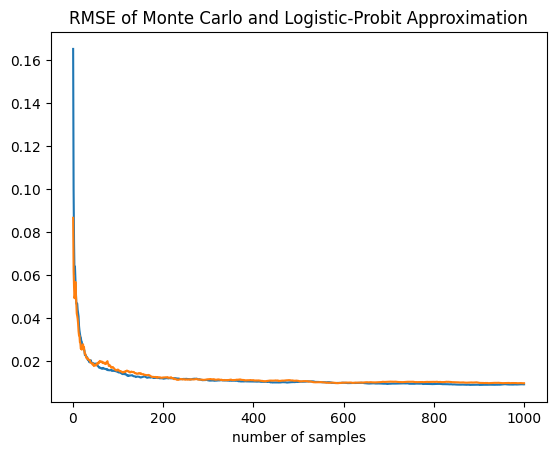

In [24]:
train_means, train_vars, train_pred = logistic_probit(laplace_posterior, X_train)
test_means, test_vars, test_pred = logistic_probit(laplace_posterior, X_test)

train_cummean = jnp.cumsum(train_samples, axis=0) / jnp.arange(1, n_samples + 1)[:, None]
test_cummean = jnp.cumsum(test_samples, axis=0) / jnp.arange(1, n_samples + 1)[:, None]

train_error = jnp.sqrt(
    jnp.mean(
        (train_cummean - train_pred[None, :]) ** 2,
        axis=1,
    )
)

test_error = jnp.sqrt(
    jnp.mean(
        (test_cummean - test_pred[None, :]) ** 2,
        axis=1,
    )
)

plt.plot(jnp.arange(1, n_samples + 1), train_error, label = "train")
plt.plot(jnp.arange(1, n_samples + 1), test_error, label = "test")
plt.xlabel("number of samples")
plt.title("RMSE of Monte Carlo and Logistic-Probit Approximation")

In the end both train and test errors are pretty small ($\approx 0.01$). They might not converge to zero necessarily since Logistic-Probit Approximation is not an exact value of expectation.

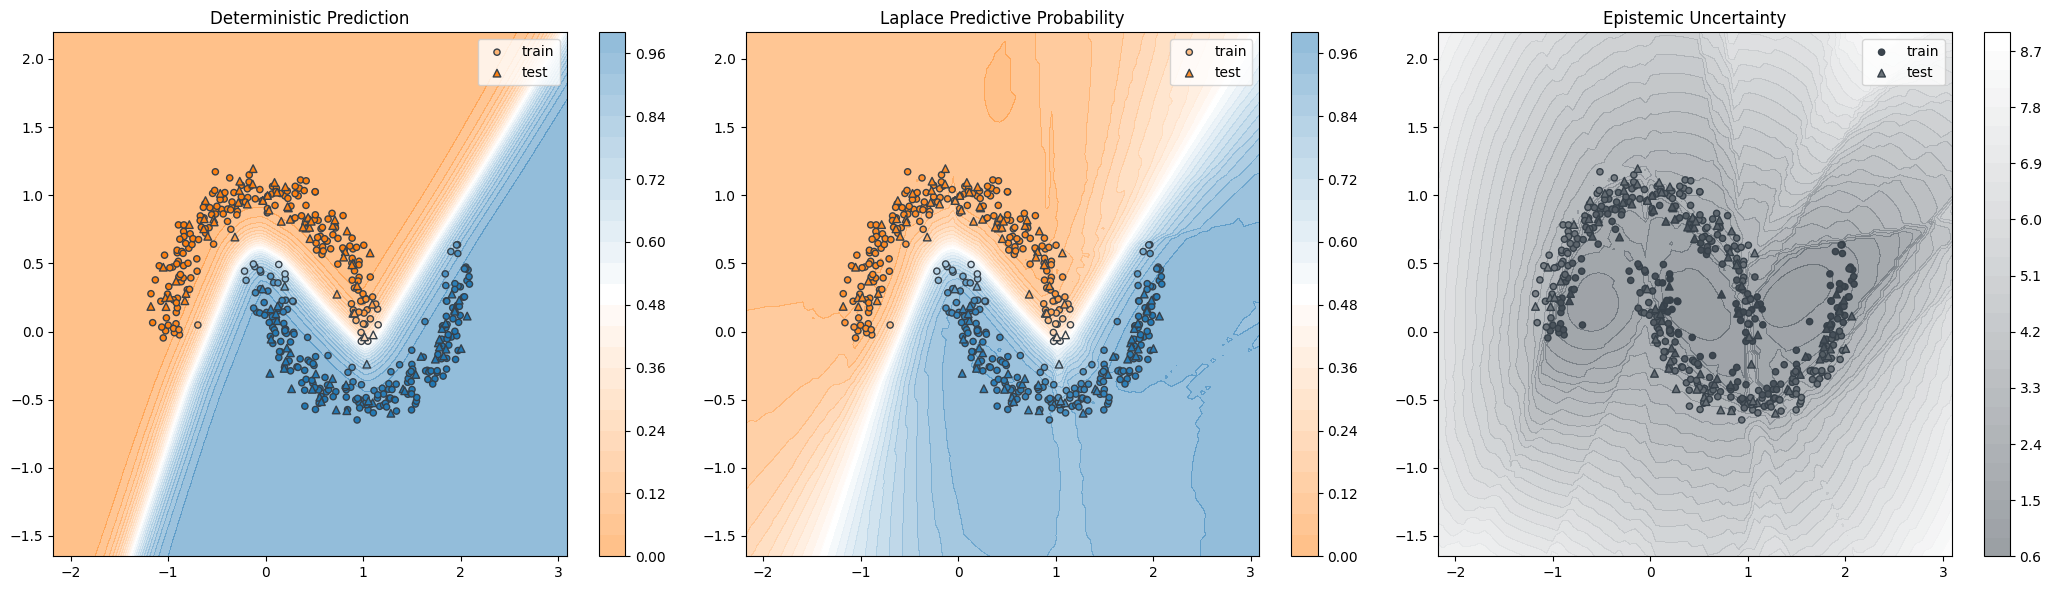

In [25]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(21, 6),
)

prediction_det = jax.nn.sigmoid(jax.vmap(model)(X_grid)).reshape(X1.shape)
train_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_train))
test_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_test))

grid_mean, grid_var, grid_pred = logistic_probit(laplace_posterior, X_grid)

grid_mean = grid_mean.reshape(X1.shape)
grid_var = grid_var.reshape(X1.shape)
grid_pred = grid_pred.reshape(X1.shape)

contour_det = plot_field(
    X1,
    X2,
    prediction_det,
    X_train,
    train_probs_det,
    X_test,
    test_probs_det,
    ax=axes[0],
    cmap=cmap,
    vmin=0,
    vmax=1,
)

axes[0].set_title("Deterministic Prediction")

contour_laplace = plot_field(
    X1,
    X2,
    grid_pred,
    X_train,
    train_probs,
    X_test,
    test_probs,
    ax=axes[1],
    cmap=cmap,
    vmin=0,
    vmax=1,
)

axes[1].set_title("Laplace Predictive Probability")

std_grid = jnp.sqrt(grid_var)

contour_std = plot_field(
    X1,
    X2,
    std_grid,
    X_train,
    jnp.sqrt(train_vars),
    X_test,
    jnp.sqrt(test_vars),
    ax=axes[2],
    cmap=dw,
    vmin=std_grid.min(),
    vmax=std_grid.max(),
)

axes[2].set_title("Epistemic Uncertainty")

fig.colorbar(contour_det, ax=axes[0])
fig.colorbar(contour_laplace, ax=axes[1])
fig.colorbar(contour_std, ax=axes[2])

for ax in axes:
    ax.legend()

plt.tight_layout()

# Distance-Aware Uncertainty: RGPR

As can be seen, the epistemic uncertainty does not increase much as we move far away from the data. That is why let us consider ReLU-GP Residual construction. The idea is to add a stochastic process obtained by integrating a Brownian motion so that uncertainty grows as we move away from the data centroid. Let us define a radial coordinate
$$ r(x) = \| x - \bar{x} \|, \quad \bar{x} = \frac{1}{N} \sum_i x_i $$
and a stochastic process
$$ g(r) = \sigma \int_0^r B_s ds $$

Brownian motion has covariance
$$ \text{Cov}(B_s, B_t) = \min (s, t) $$
thus,
$$ \text{Cov}(g(r), g(r')) = \sigma^2 \int_0^r \int_0^{r'} \min(s, t) ds dt $$
let
$$ m = \min (r, r'), \quad M = \max (r, r') $$
then,
$$ k_{\text{RGPR}}(r, r') = \text{Cov}(g(r), g(r')) = \sigma^2 \left[ \frac{m^3}{3} + \frac{(M - m)m^2}{2} \right] $$
or, equivalently,
$$ k_{\text{RGPR}}(r, r') = \sigma^2 \left[ \frac{m^3}{3} + \frac{|r - r'| m^2}{2} \right] $$

For point epistemic uncertainty,
$$ k_{\text{RGPR}}(r, r) = \frac{\sigma^2 r^3}{3} $$
so it grows cubically with respect to the distance from the data centroid.

Since adding to legit covariance kernels result in a covariance kernel, our total kernel for the process will be
$$ \boxed{k(x, x') = J(x) \Sigma_{\theta} J(x')^T + k_{\text{RGPR}}(r(x), r(x'))} $$

In [26]:
center = X_train.mean(axis = 0)
sigma_rgpr = 5

def k_rgpr(a, b, sigma_rgpr = sigma_rgpr):
    ra = jnp.linalg.norm(a - center, axis=-1)
    rb = jnp.linalg.norm(b - center, axis=-1)

    m = jnp.minimum(ra, rb)

    return sigma_rgpr**2 * (m**3 / 3 + jnp.abs(ra - rb) * m**2 / 2)

def total_covariance_fn(a, b):
    return laplace_covariance_fn(a, b) + k_rgpr(a, b)

rgpr_posterior = GaussianProcess(mean_fn, total_covariance_fn)

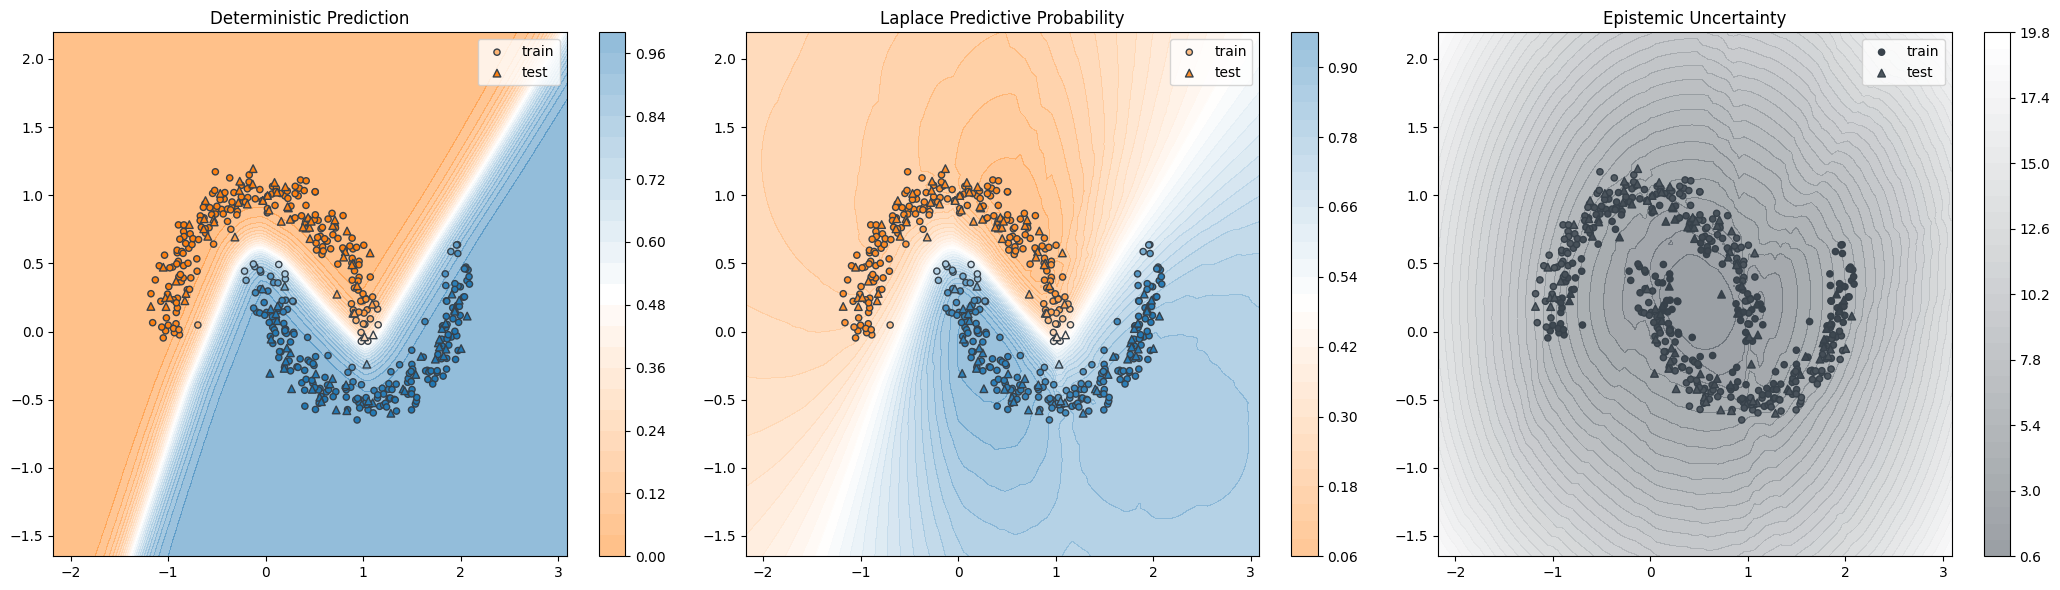

In [27]:
train_mean, train_var, train_pred = logistic_probit(rgpr_posterior, X_train)
test_mean, test_var, test_pred = logistic_probit(rgpr_posterior, X_test)
grid_mean, grid_var, grid_pred = logistic_probit(rgpr_posterior, X_grid)

grid_mean = grid_mean.reshape(X1.shape)
grid_var = grid_var.reshape(X1.shape)
grid_pred = grid_pred.reshape(X1.shape)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(21, 6),
)

contour_det = plot_field(
    X1,
    X2,
    prediction_det,
    X_train,
    train_probs_det,
    X_test,
    test_probs_det,
    ax=axes[0],
    cmap=cmap,
    vmin=0,
    vmax=1,
)

axes[0].set_title("Deterministic Prediction")

contour_laplace = plot_field(
    X1,
    X2,
    grid_pred,
    X_train,
    train_probs,
    X_test,
    test_probs,
    ax=axes[1],
    cmap=cmap,
    vmin=0,
    vmax=1,
)

axes[1].set_title("Laplace Predictive Probability")

std_grid = jnp.sqrt(grid_var)

contour_std = plot_field(
    X1,
    X2,
    std_grid,
    X_train,
    jnp.sqrt(train_vars),
    X_test,
    jnp.sqrt(test_vars),
    ax=axes[2],
    cmap=dw,
    vmin=std_grid.min(),
    vmax=std_grid.max(),
)

axes[2].set_title("Epistemic Uncertainty")

fig.colorbar(contour_det, ax=axes[0])
fig.colorbar(contour_laplace, ax=axes[1])
fig.colorbar(contour_std, ax=axes[2])

for ax in axes:
    ax.legend()

plt.tight_layout()

# Experiments

In this section we will see how different settings affect the results. Since we will change the prior and dataset size, we will need to re-train the model to obtain different $\theta_{\text{MAP}}$. That is why let us write a function that will calculate GGN and Laplace covariance based on model parameters and return the final Gaussian Process.

In [28]:
def make_laplace_gp(model, X_train, y_train, prior_var = 1.0, sigma_rgpr = None):
    params, static = eqx.partition(model, eqx.is_array)

    # ----- GGN -----

    def model_fn(input, params):
        model_ = eqx.combine(params, static)
        return model_(input).squeeze()

    data = {
        "input": X_train,
        "target": y_train,
    }

    ggn_mv = create_ggn_mv(
        model_fn=model_fn,
        params=params,
        data=data,
        loss_fn=LossFn.BINARY_CROSS_ENTROPY,
    )

    flatten, unflatten = create_pytree_flattener(params)

    ggn_flat_mv = wrap_function(
        ggn_mv,
        input_fn=unflatten,
        output_fn=flatten,
    )

    P = get_size(params)
    G = to_dense(ggn_flat_mv, layout=P)

    # ----- parameter-space posterior -----

    H = G + jnp.eye(P) / prior_var

    theta, unravel = ravel_pytree(params)

    def model_flat(theta, x):
        params_ = unravel(theta)
        model_ = eqx.combine(params_, static)
        return model_(x).squeeze()

    jac_single = jax.jacrev(model_flat, argnums=0)

    # ----- function-space posterior -----

    def mean_fn(x):
        return jax.vmap(model)(x).squeeze(-1)

    def jac_fn(x):
        shape = x.shape[:-1]
        x_flat = x.reshape(-1, x.shape[-1])

        J = jax.vmap(
            jac_single,
            in_axes=(None, 0),
        )(theta, x_flat)

        return J.reshape(*shape, -1)

    def covariance_fn(a, b, sigma_rgpr = sigma_rgpr):
        J_a = jac_fn(a)
        J_b = jac_fn(b)

        Hinv_Jb = jnp.linalg.solve(
            H,
            J_b[..., None],
        )[..., 0]

        if sigma_rgpr is None:
            return jnp.sum(J_a * Hinv_Jb, axis=-1)
        else:
            return jnp.sum(J_a * Hinv_Jb, axis=-1) + k_rgpr(a, b, sigma_rgpr)

    return GaussianProcess(mean_fn, covariance_fn)

## Prior Precision

Let us first examine how does prior precision
$$ V^{-1} $$
affect the resulting posterior.

Let us assume that
$$ V = \sigma_{\text{prior}}^2 I $$
and treat $\sigma_{\text{prior}}$ as a parameter.

Since
$$ \Sigma_{\theta} = (G + V^{-1})^{-1} = (G + \sigma_{\text{prior}}^{-2} I)^{-1} $$
analytically,
$$ \Sigma_{\theta} \to G^{-1} \quad \text{as} \quad \sigma_{\text{prior}} \to \infty $$
$$ \Sigma_{\theta} \to 0 \quad \text{as} \quad \sigma_{\text{prior}} \to 0 $$

In this experiment let us drop the RGPR kernel so that we can inspect the raw impact of the prior precision on the posterior distribution.

Training: 100%|██████████| 300/300 [00:02<00:00, 138.99it/s, epoch=300, test_accuracy=1, test_loss=0.711, train_loss=0.0146]   


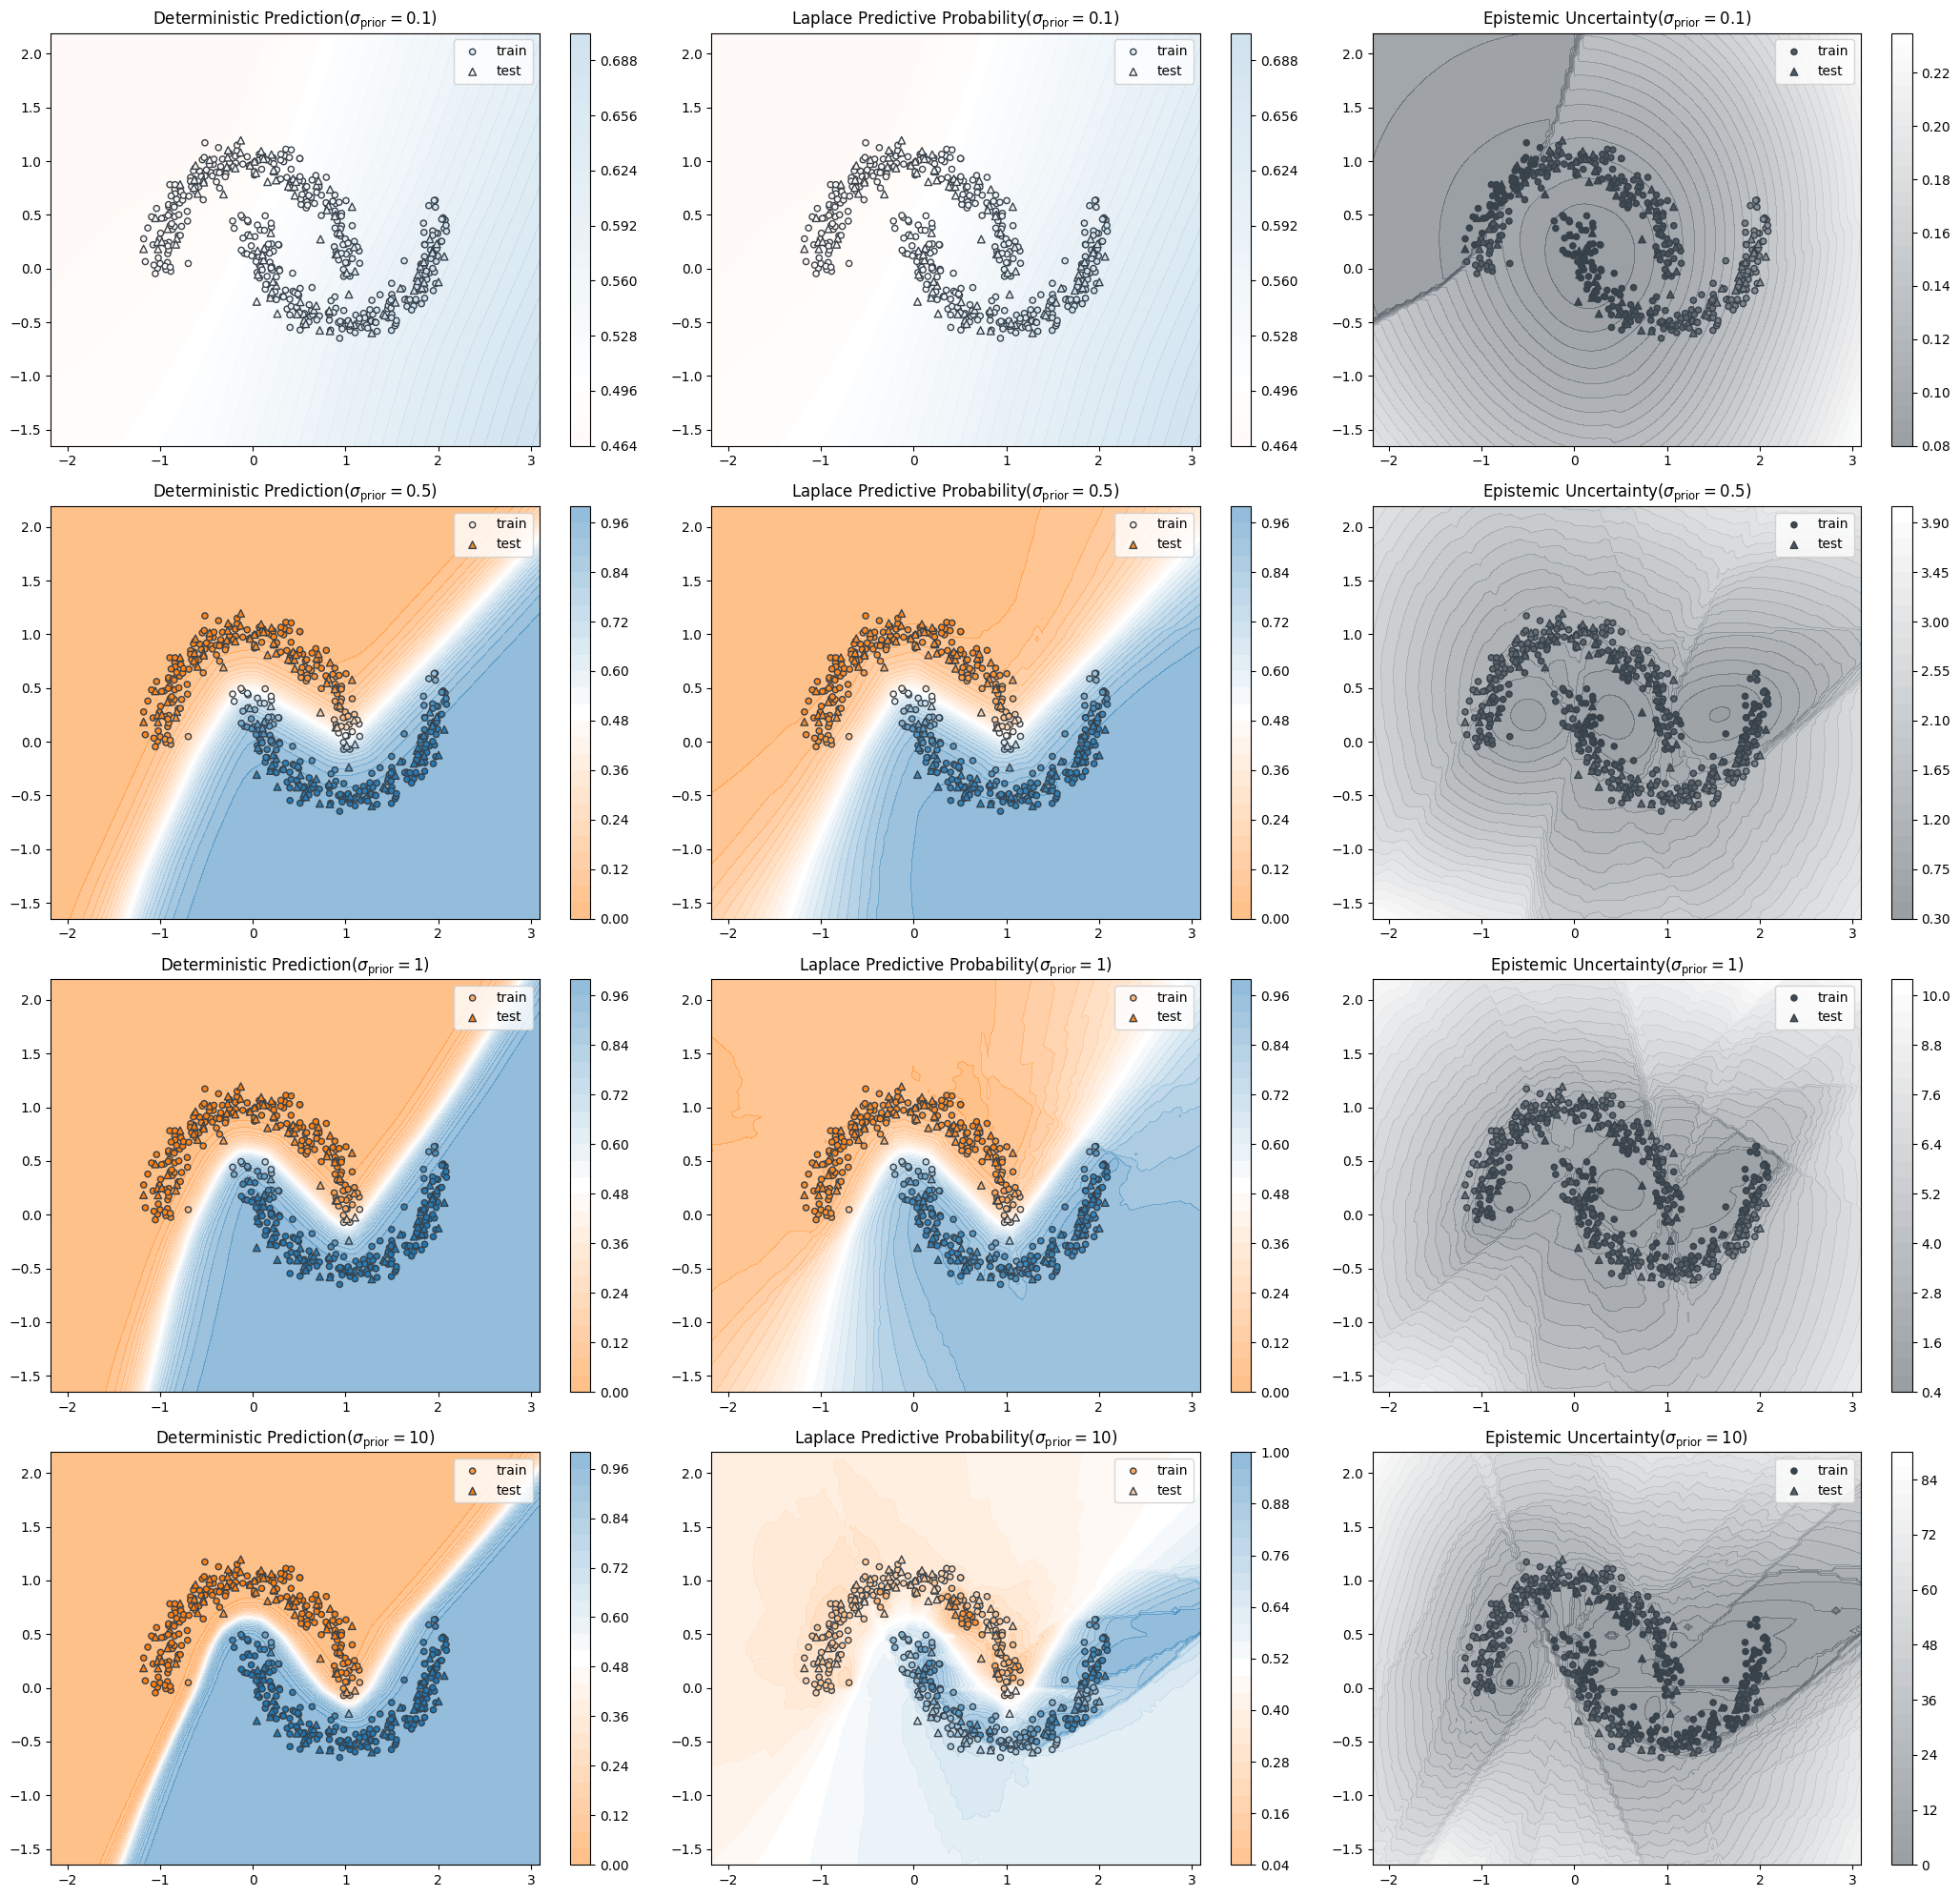

In [29]:
sigma_prior_grid = [0.1, 0.5, 1, 10]

fig, axes = plt.subplots(nrows = len(sigma_prior_grid), ncols = 3, figsize = (21, 20))

ax = axes.flatten()

for i, sigma_prior in enumerate(sigma_prior_grid):
    model_key, KEY = random.split(KEY, 2)
    model = MLP(model_key, LAYER_SIZES)

    optimizer = optax.adam(learning_rate = LEARNING_RATE)
    model, _ = train(model, train_loader, test_loader, optimizer, num_epochs = NUM_EPOCHS, prior_var = sigma_prior**2)

    train_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_train))
    test_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_test))
    grid_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_grid)).reshape(X1.shape)

    laplace_posterior = make_laplace_gp(model, X_train, y_train, prior_var = sigma_prior**2)
    
    train_mean, train_var, train_pred = logistic_probit(laplace_posterior, X_train)
    test_mean, test_var, test_pred = logistic_probit(laplace_posterior, X_test)
    grid_mean, grid_var, grid_pred = logistic_probit(laplace_posterior, X_grid)

    grid_mean = grid_mean.reshape(X1.shape)
    grid_var = grid_var.reshape(X1.shape)
    grid_pred = grid_pred.reshape(X1.shape)

    contour_det = plot_field(
        X1,
        X2,
        grid_probs_det,
        X_train,
        train_probs_det,
        X_test,
        test_probs_det,
        ax=ax[3 * i],
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    ax[3 * i].set_title(fr"Deterministic Prediction($\sigma_{{\text{{prior}}}} = {sigma_prior}$)")

    contour_laplace = plot_field(
        X1,
        X2,
        grid_pred,
        X_train,
        train_pred,
        X_test,
        test_pred,
        ax=ax[3 * i + 1],
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    ax[3 * i + 1].set_title(fr"Laplace Predictive Probability($\sigma_{{\text{{prior}}}} = {sigma_prior}$)")

    std_grid = jnp.sqrt(grid_var)

    contour_std = plot_field(
        X1,
        X2,
        std_grid,
        X_train,
        jnp.sqrt(train_var),
        X_test,
        jnp.sqrt(test_var),
        ax=ax[3 * i + 2],
        cmap=dw,
        vmin=std_grid.min(),
        vmax=std_grid.max(),
    )

    ax[3 * i + 2].set_title(fr"Epistemic Uncertainty($\sigma_{{\text{{prior}}}} = {sigma_prior}$)")

    fig.colorbar(contour_det, ax=ax[3 * i])
    fig.colorbar(contour_laplace, ax=ax[3 * i + 1])
    fig.colorbar(contour_std, ax=ax[3 * i + 2])

for i in ax:
    i.legend()

plt.tight_layout()

The prior variance strongly affects both the MAP solution and the posterior uncertainty. A very small variance (\(0.1\)) over-regularizes the network, collapsing predictions toward \(0.5\), while a very large variance (\(10\)) allows a more irregular MAP solution and produces extremely large epistemic uncertainty. Intermediate values (\(0.5\)–\(1\)) give a more stable classifier with moderate uncertainty.

So the experiment illustrates the expected trade-off:

$$
\boxed{
\text{small prior variance}
\rightarrow
\text{strong regularization},
\qquad
\text{large prior variance}
\rightarrow
\text{weak regularization and larger posterior uncertainty}.
}
$$

In this example, neither extreme is particularly useful.

## Effect of Dataset Size

Training: 100%|██████████| 300/300 [00:01<00:00, 155.95it/s, epoch=300, test_accuracy=1, test_loss=0.383, train_loss=0.13]    


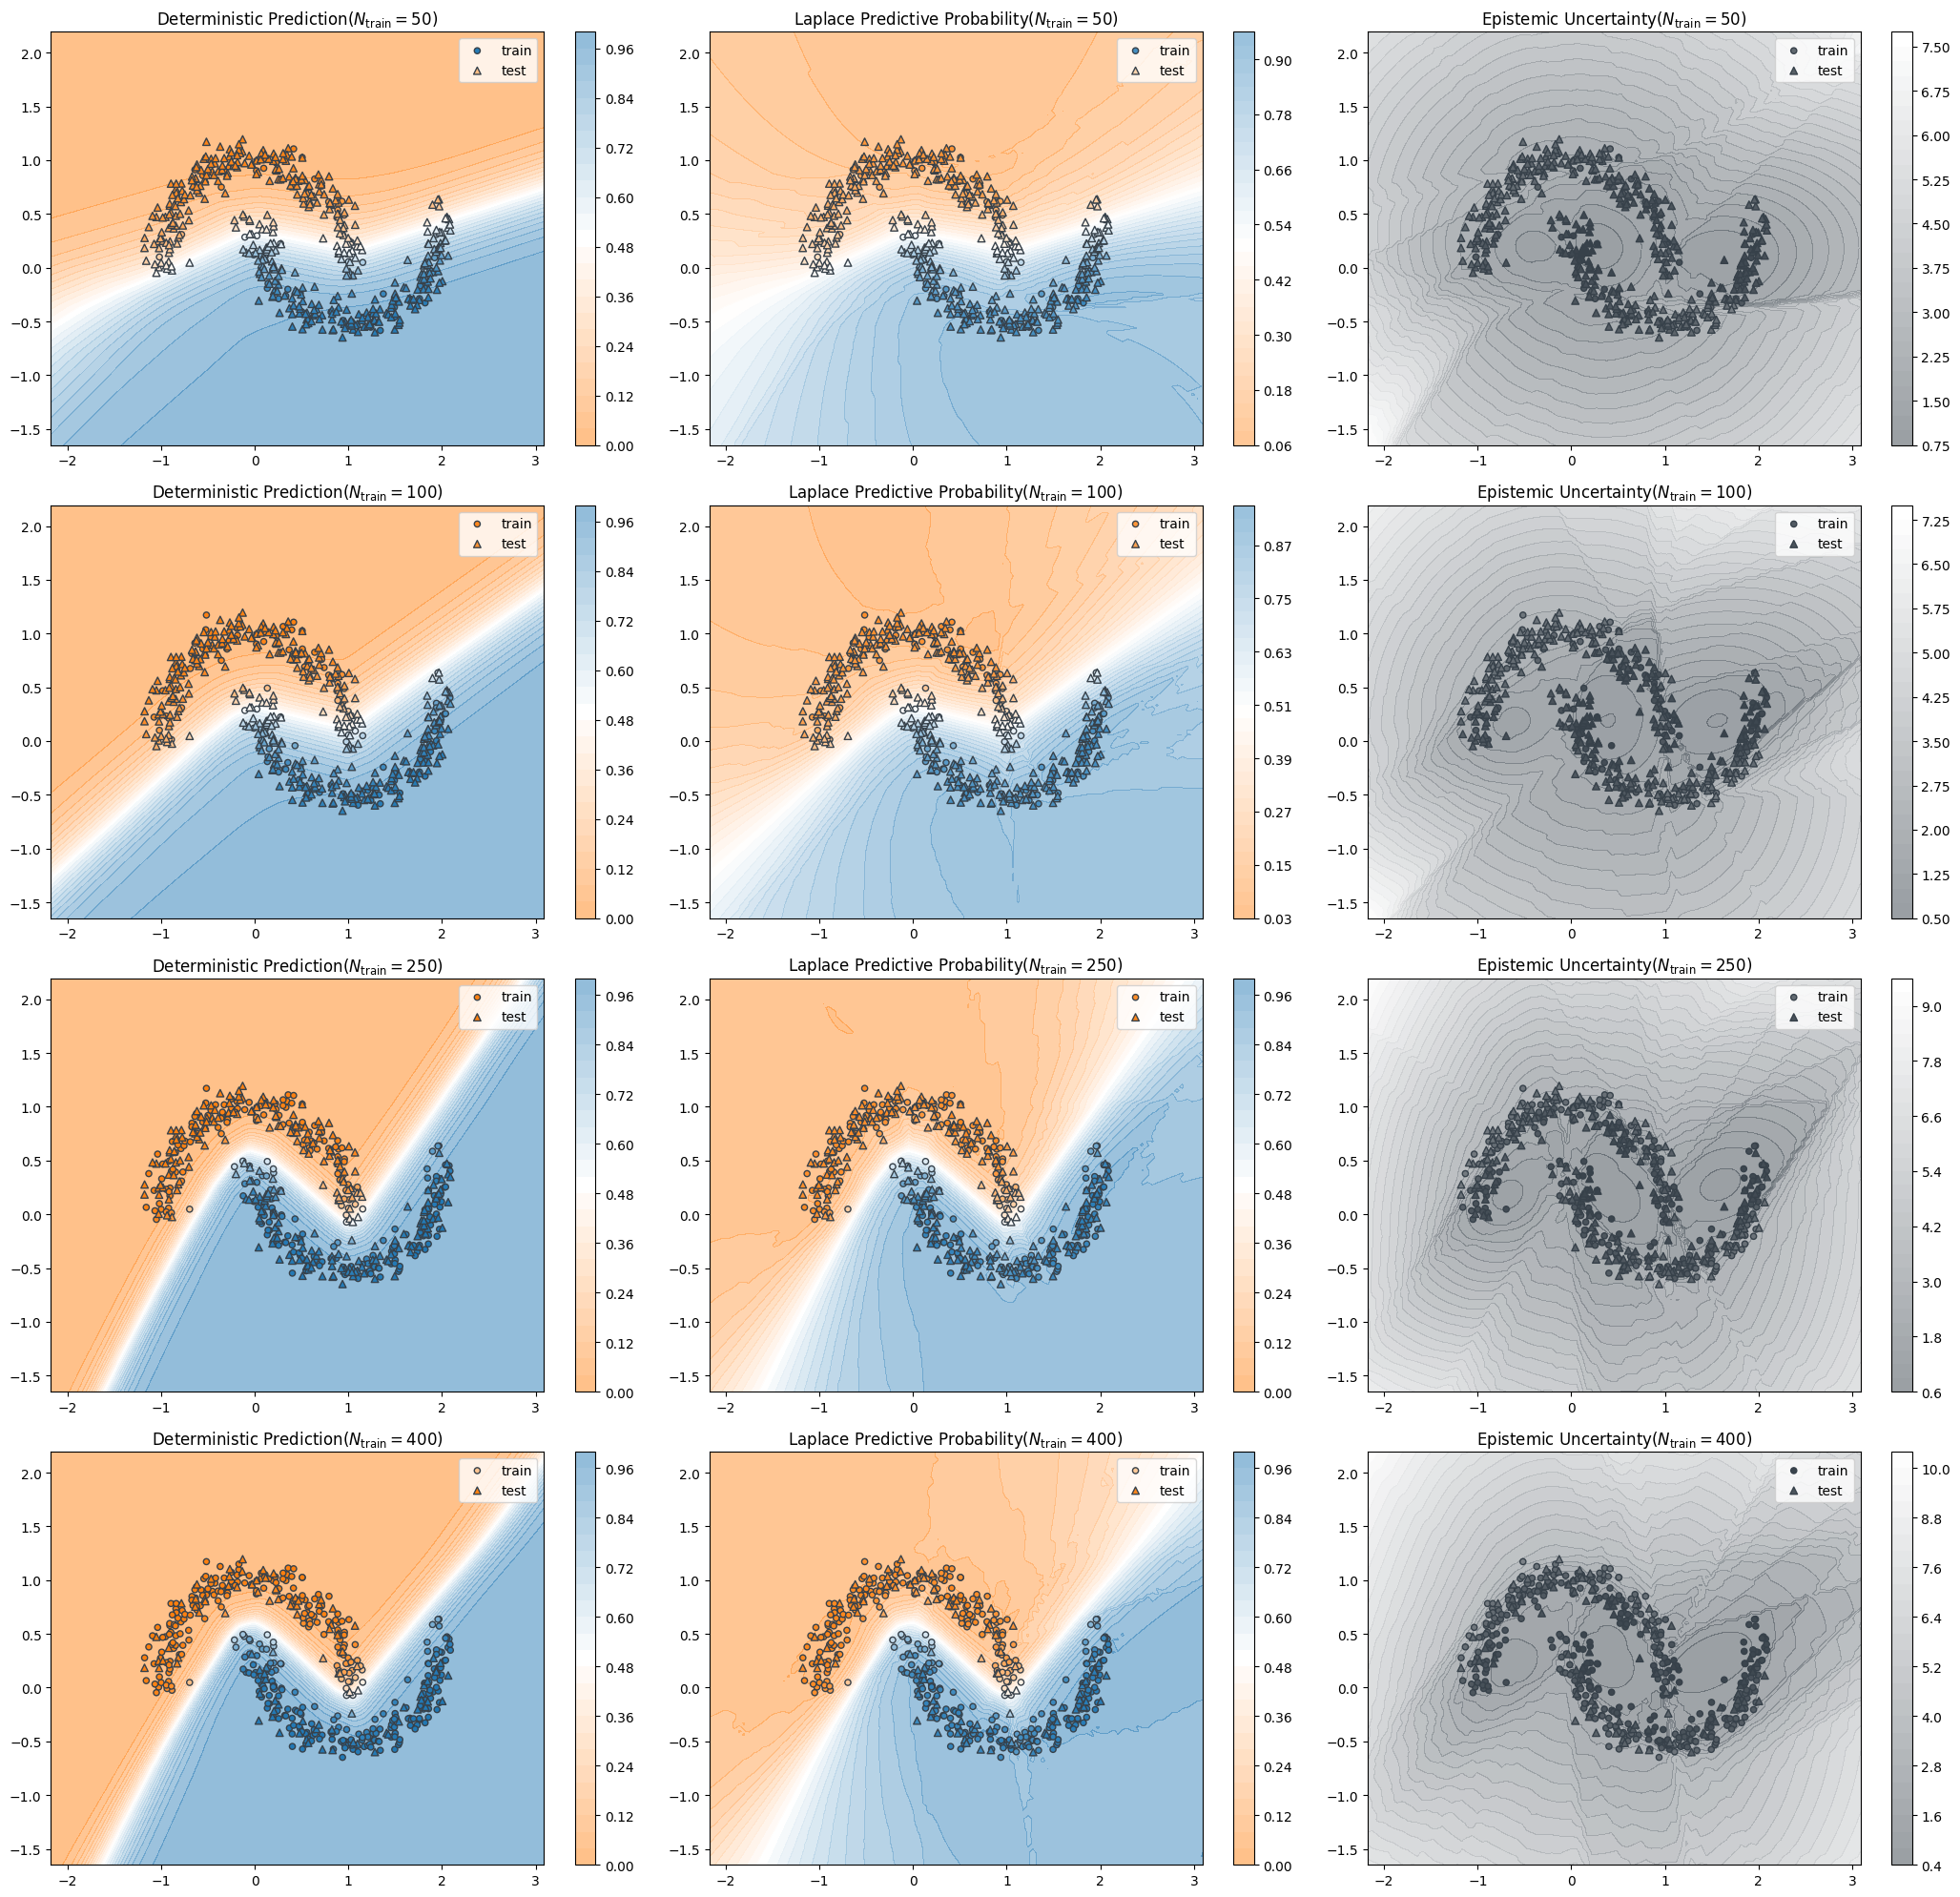

In [30]:
test_size_grid = [0.9, 0.8, 0.5, 0.2]   #training dataset size of 50, 100, 250, 400

fig, axes = plt.subplots(nrows = len(test_size_grid), ncols = 3, figsize = (21, 20))

ax = axes.flatten()

for i, test_size in enumerate(test_size_grid):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, shuffle = True, random_state = 47)

    center_i = X_train.mean(axis = 0)

    train_dataset = MyDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = len(train_dataset), shuffle = False)

    test_dataset = MyDataset(X_test, y_test)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = len(test_dataset), shuffle = False)

    model_key, KEY = random.split(KEY, 2)
    model = MLP(model_key, LAYER_SIZES)

    optimizer = optax.adam(learning_rate = LEARNING_RATE)
    model, _ = train(model, train_loader, test_loader, optimizer, num_epochs = NUM_EPOCHS, prior_var = 1.0)

    train_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_train))
    test_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_test))
    grid_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_grid)).reshape(X1.shape)

    laplace_posterior = make_laplace_gp(model, X_train, y_train, prior_var = 1.0)
    
    train_mean, train_var, train_pred = logistic_probit(laplace_posterior, X_train)
    test_mean, test_var, test_pred = logistic_probit(laplace_posterior, X_test)
    grid_mean, grid_var, grid_pred = logistic_probit(laplace_posterior, X_grid)

    grid_mean = grid_mean.reshape(X1.shape)
    grid_var = grid_var.reshape(X1.shape)
    grid_pred = grid_pred.reshape(X1.shape)

    contour_det = plot_field(
        X1,
        X2,
        grid_probs_det,
        X_train,
        train_probs_det,
        X_test,
        test_probs_det,
        ax=ax[3 * i],
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    ax[3 * i].set_title(fr"Deterministic Prediction($N_{{\text{{train}}}} = {len(X_train)}$)")

    contour_laplace = plot_field(
        X1,
        X2,
        grid_pred,
        X_train,
        train_pred,
        X_test,
        test_pred,
        ax=ax[3 * i + 1],
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    ax[3 * i + 1].set_title(fr"Laplace Predictive Probability($N_{{\text{{train}}}} = {len(X_train)}$)")

    std_grid = jnp.sqrt(grid_var)

    contour_std = plot_field(
        X1,
        X2,
        std_grid,
        X_train,
        jnp.sqrt(train_var),
        X_test,
        jnp.sqrt(test_var),
        ax=ax[3 * i + 2],
        cmap=dw,
        vmin=std_grid.min(),
        vmax=std_grid.max(),
    )

    ax[3 * i + 2].set_title(fr"Epistemic Uncertainty($N_{{\text{{train}}}} = {len(X_train)}$)")

    fig.colorbar(contour_det, ax=ax[3 * i])
    fig.colorbar(contour_laplace, ax=ax[3 * i + 1])
    fig.colorbar(contour_std, ax=ax[3 * i + 2])

for i in ax:
    i.legend()

plt.tight_layout()

As the training set grows, the deterministic and Laplace predictions become more stable and better aligned with the two-moons structure. With only \(N_{\text{train}}=50\), the decision boundary and predictive probabilities are more strongly influenced by limited data, while larger datasets produce a cleaner and more consistent classifier.

The epistemic uncertainty, however, does **not decrease monotonically everywhere** as \(N_{\text{train}}\) increases. This is expected because retraining changes both the MAP solution and the Jacobian \(J(x)\), so

$$
v(x)=J(x)\Sigma_\theta J(x)^T
$$

can change non-monotonically pointwise even though additional data generally provide more information about the parameters.

So the main conclusion is

$$
\boxed{
N_{\text{train}}\uparrow
\;\Rightarrow\;
\text{more stable predictive behavior and better constrained posterior directions},
}
$$

but not necessarily uniformly smaller function-space variance at every input.

## Effect of RGPR Scale

Now let us examine how does the RGPR scale $\sigma_{\text{RGPR}}$ affect the predictive distribution.

Training:   0%|          | 0/300 [00:00<?, ?it/s]

Training: 100%|██████████| 300/300 [00:02<00:00, 139.62it/s, epoch=300, test_accuracy=1, test_loss=0.376, train_loss=0.122]   


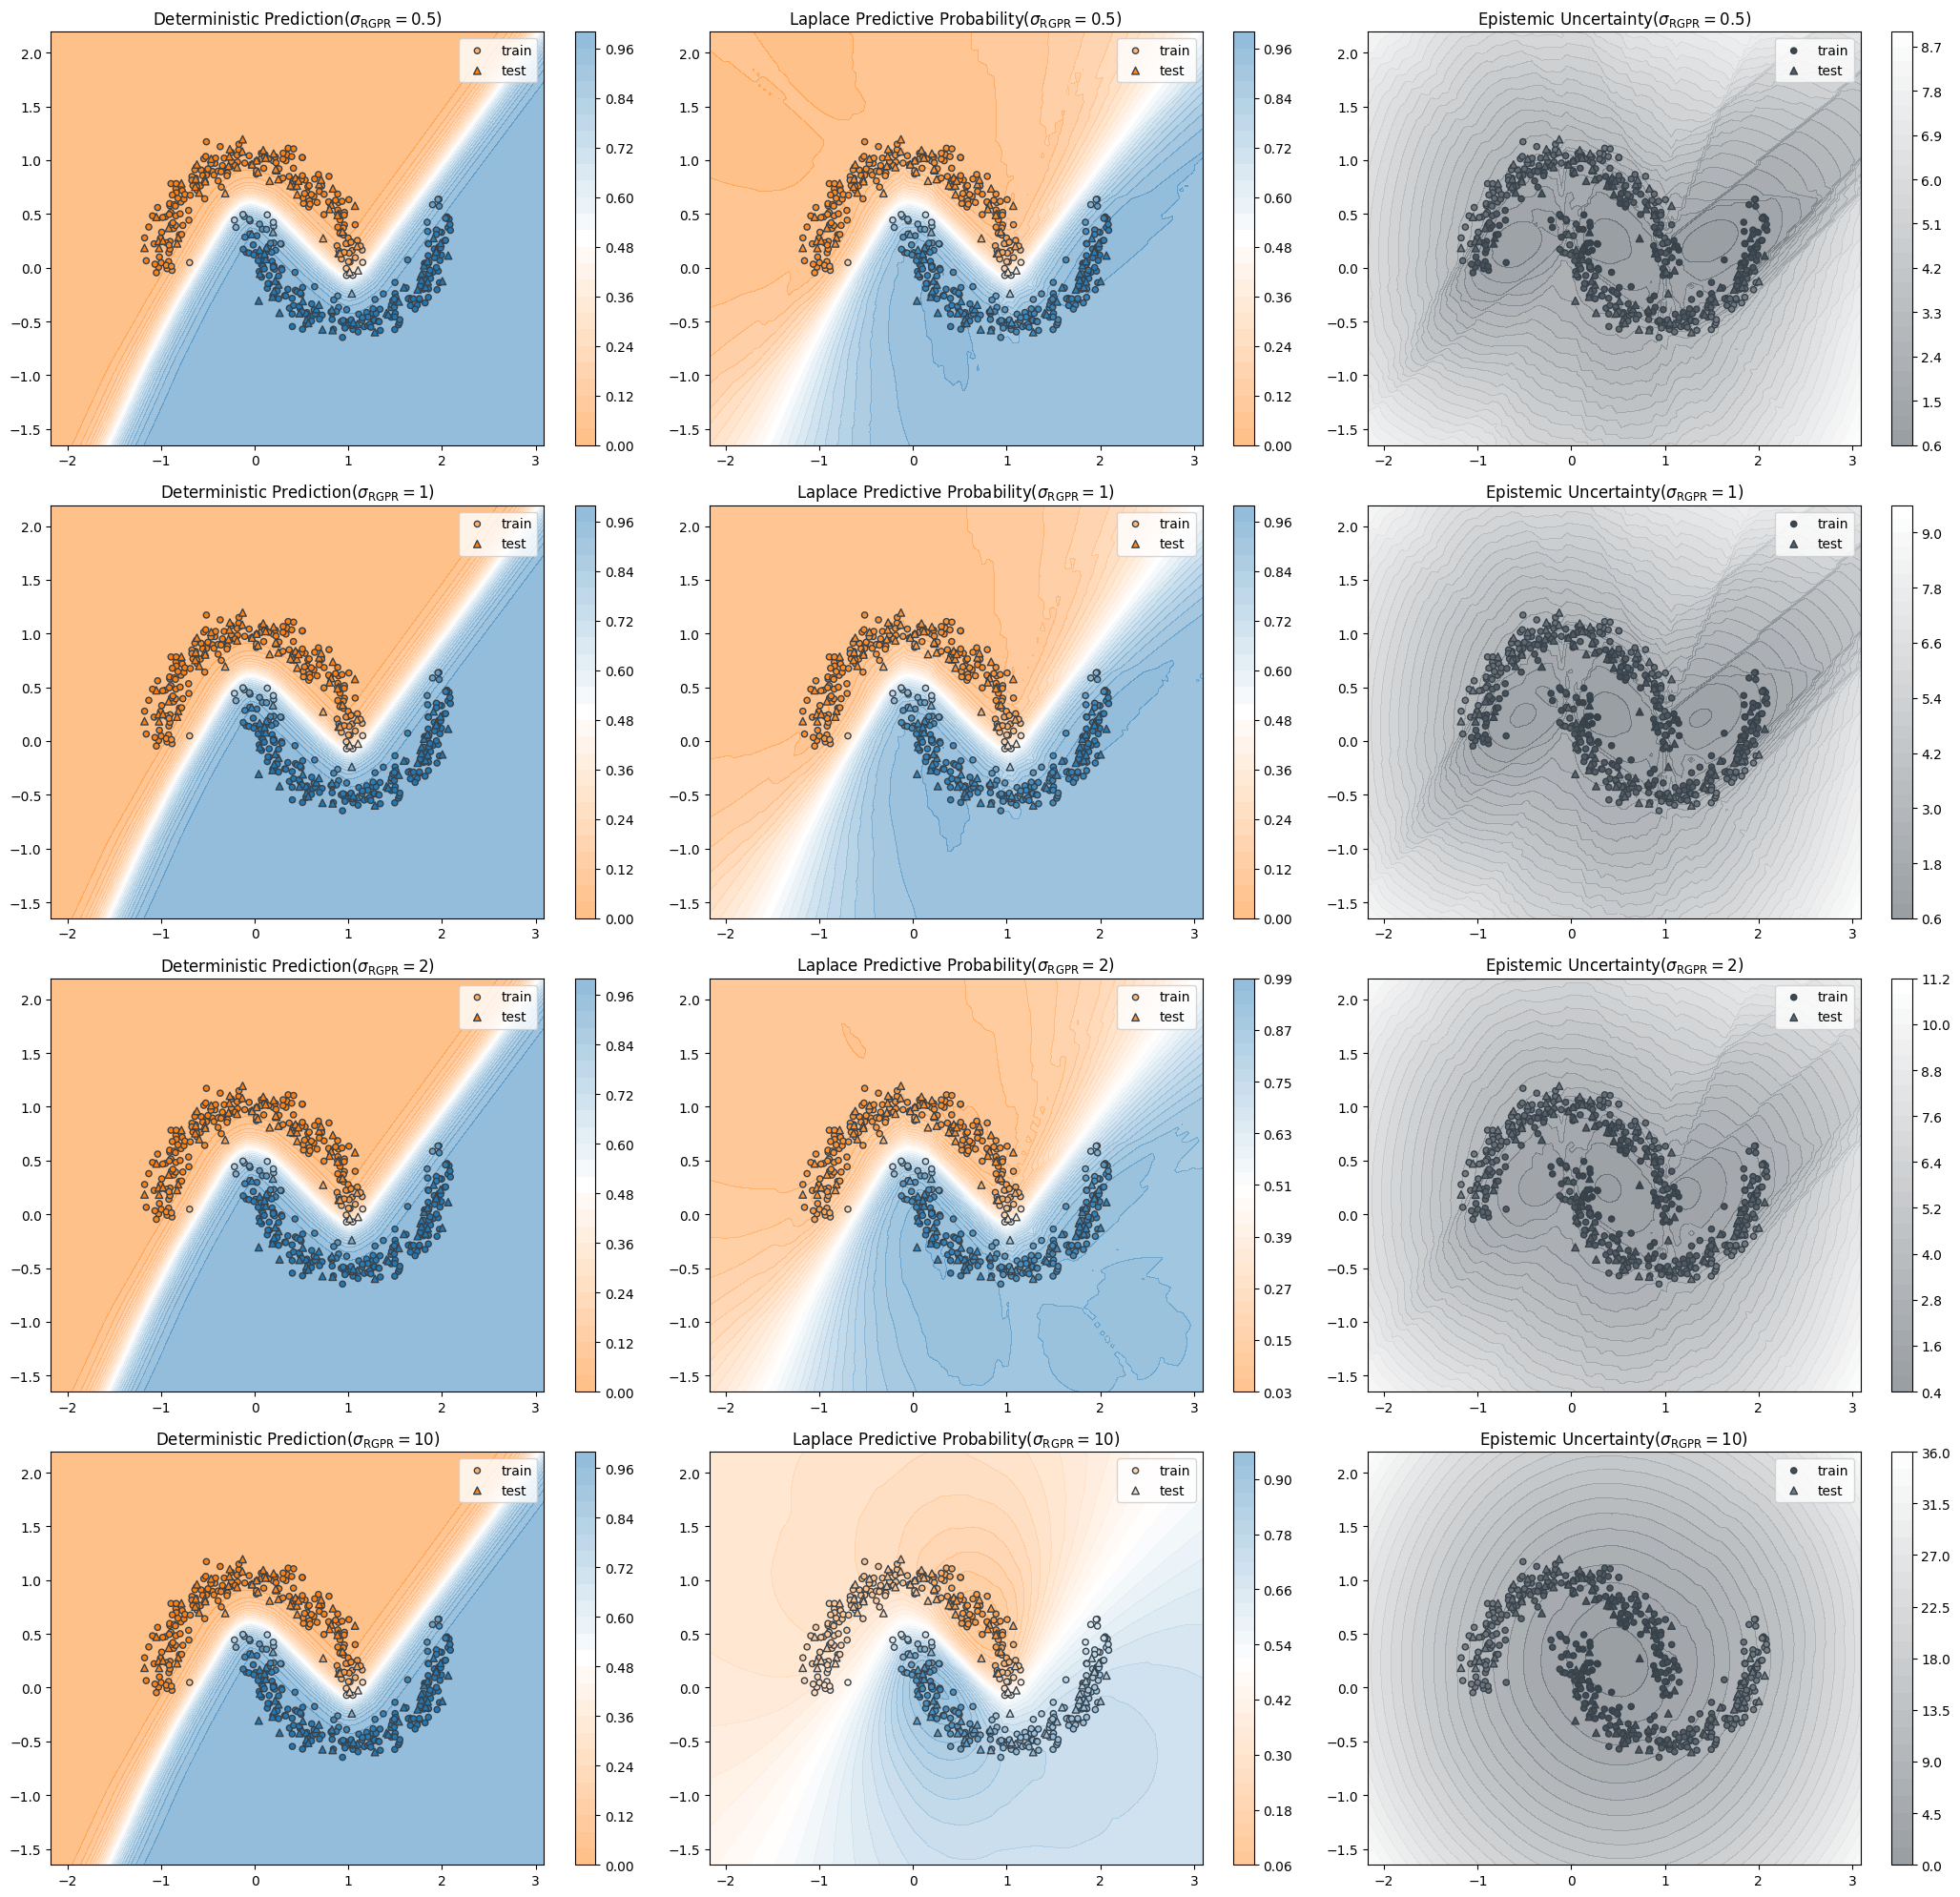

In [31]:
sigma_rgpr_grid = [0.5, 1, 2, 10]

fig, axes = plt.subplots(nrows = len(sigma_rgpr_grid), ncols = 3, figsize = (21, 20))

ax = axes.flatten()

model_key, KEY = random.split(KEY, 2)
model = MLP(model_key, LAYER_SIZES)

optimizer = optax.adam(learning_rate = LEARNING_RATE)
model, _ = train(model, train_loader, test_loader, optimizer, num_epochs = NUM_EPOCHS, prior_var = 1.0)

train_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_train))
test_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_test))
grid_probs_det = jax.nn.sigmoid(jax.vmap(model)(X_grid)).reshape(X1.shape)

for i, sigma_rgpr in enumerate(sigma_rgpr_grid):
    laplace_posterior = make_laplace_gp(model, X_train, y_train, prior_var = 1.0, sigma_rgpr = sigma_rgpr)
    
    train_mean, train_var, train_pred = logistic_probit(laplace_posterior, X_train)
    test_mean, test_var, test_pred = logistic_probit(laplace_posterior, X_test)
    grid_mean, grid_var, grid_pred = logistic_probit(laplace_posterior, X_grid)

    grid_mean = grid_mean.reshape(X1.shape)
    grid_var = grid_var.reshape(X1.shape)
    grid_pred = grid_pred.reshape(X1.shape)

    contour_det = plot_field(
        X1,
        X2,
        grid_probs_det,
        X_train,
        train_probs_det,
        X_test,
        test_probs_det,
        ax=ax[3 * i],
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    ax[3 * i].set_title(fr"Deterministic Prediction($\sigma_{{\text{{RGPR}}}} = {sigma_rgpr}$)")

    contour_laplace = plot_field(
        X1,
        X2,
        grid_pred,
        X_train,
        train_pred,
        X_test,
        test_pred,
        ax=ax[3 * i + 1],
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    ax[3 * i + 1].set_title(fr"Laplace Predictive Probability($\sigma_{{\text{{RGPR}}}} = {sigma_rgpr}$)")

    std_grid = jnp.sqrt(grid_var)

    contour_std = plot_field(
        X1,
        X2,
        std_grid,
        X_train,
        jnp.sqrt(train_var),
        X_test,
        jnp.sqrt(test_var),
        ax=ax[3 * i + 2],
        cmap=dw,
        vmin=std_grid.min(),
        vmax=std_grid.max(),
    )

    ax[3 * i + 2].set_title(fr"Epistemic Uncertainty($\sigma_{{\text{{RGPR}}}} = {sigma_rgpr}$)")

    fig.colorbar(contour_det, ax=ax[3 * i])
    fig.colorbar(contour_laplace, ax=ax[3 * i + 1])
    fig.colorbar(contour_std, ax=ax[3 * i + 2])

for i in ax:
    i.legend()

plt.tight_layout()

As \(\sigma_{\text{RGPR}}\) increases, the deterministic prediction remains unchanged, while the added distance-aware covariance substantially increases epistemic uncertainty away from the training region. Consequently, the Bayesian predictive probabilities are increasingly pulled toward \(0.5\) in poorly supported regions.

$$
\boxed{
\sigma_{\text{RGPR}}\uparrow
\;\Rightarrow\;
\text{stronger distance-dependent uncertainty}
\;\Rightarrow\;
\text{more conservative OOD predictions}.
}
$$

For very large values such as \(\sigma_{\text{RGPR}}=10\), the added RGPR uncertainty begins to dominate the original Laplace posterior, illustrating that \(\sigma_{\text{RGPR}}\) controls the strength of an explicit modeling assumption rather than uncertainty learned from the data.


# Parameter Space vs Function Space

The Laplace approximation first gives a posterior over the network parameters:

$$ q(\theta \mid \mathcal D) = \mathcal N(\theta_{\text{MAP}}, \Sigma_\theta). $$

This is the parameter-space view: uncertainty is represented directly over the network weights.

After linearization, this uncertainty can be pushed forward to function space:

$$ q(f \mid \mathcal D) = \mathcal{GP}\left( m, k \right), $$

where

$$ m(x)=f(x;\theta_{\text{MAP}}), \qquad k(x,x')=J(x)\Sigma_\theta J(x')^T. $$

The function-space view is often easier to interpret, since it describes uncertainty directly in the model predictions rather than in thousands of individual parameters.

# Limitations

The presented approach relies on several approximations:

- Laplace approximates the posterior locally around $\theta_{\text{MAP}}$ with a Gaussian.
- GGN approximates the true neural network Hessian.
- Linearization only describes the network locally in parameter space.
- RGPR introduces distance-aware uncertainty as an additional modeling assumption.
- The logistic-probit approximation is not the exact predictive integral.

For larger neural networks, storing and inverting the full posterior covariance also becomes computationally expensive.

# Conclusion

We started with a deterministic neural network and obtained a Bayesian approximation by combining MAP estimation, Laplace approximation, and local linearization.

The resulting parameter posterior

$$
q(\theta \mid \mathcal D)
=
\mathcal N(\theta_{\text{MAP}}, \Sigma_\theta)
$$

induces an approximate Gaussian process in function space,

$$
q(f \mid \mathcal D)
=
\mathcal{GP}\left(
f(\cdot;\theta_{\text{MAP}}),
J(\cdot)\Sigma_\theta J(\cdot)^T
\right).
$$

This allows us to represent epistemic uncertainty in neural network predictions, while RGPR can additionally impose uncertainty growth away from the observed data.